# NBA Tanking: A Game Theory & Data Analysis

**Author:** Darren Schell  
**GitHub:** github.com/dschell3

This notebook models the strategic incentive to lose games ("tank") in the NBA draft system using game theory, Monte Carlo simulation, and real draft lottery data. It also evaluates a proposed reform — a "hockey model" — inspired by the PWHL draft system.

### Sections
1. [Single-Team Utility Model](#1)
2. [Two-Player Prisoner's Dilemma](#2)
3. [Superstar Year & Franchise Value](#3)
4. [Monte Carlo: League Strategy Dynamics](#4)
5. [Real NBA Data: Hockey Model Retroactive Analysis](#5)
6. [Summary & Findings](#6)

In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
import warnings
warnings.filterwarnings('ignore')

# ── Global plot style ──────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#0d0f14',
    'axes.facecolor':   '#14171f',
    'axes.edgecolor':   '#2a2e3a',
    'axes.labelcolor':  '#e8e6df',
    'xtick.color':      '#7a7870',
    'ytick.color':      '#7a7870',
    'text.color':       '#e8e6df',
    'grid.color':       '#1e2230',
    'grid.linestyle':   '--',
    'grid.alpha':       0.5,
    'font.family':      'monospace',
    'axes.titlesize':   13,
    'axes.labelsize':   11,
})

# ── Color palette ──────────────────────────────────────────────────────────────
C_TANK    = '#e05252'   # red    — Tank strategy
C_COMPETE = '#4a9eda'   # blue   — Compete strategy
C_AMBER   = '#f0a500'   # amber  — highlights
C_GREEN   = '#3dba8a'   # teal   — positive outcomes
C_MUTED   = '#7a7870'   # grey   — annotations

print('Libraries loaded. Ready.')

Libraries loaded. Ready.


<a id='1'></a>
## Section 1 — Single-Team Utility Model

A team with no playoff chance chooses between two strategies: **Tank** (lose intentionally for draft position) or **Compete** (field best available roster).

Their utility is modeled as:

$$U(s) = \alpha \cdot \hat{D}(s) + \beta \cdot R(s)$$

| Parameter | Meaning |
|-----------|----------|
| $\alpha$ | Weight placed on draft pick value |
| $\beta$  | Weight placed on season revenue |
| $\hat{D}(s)$ | Expected draft pick value under strategy $s$ |
| $R(s)$   | Season revenue under strategy $s$ |

**Hardcoded values** (calibrated from NBA revenue sharing data):
- Tank: D̂ = 72, R = 20
- Compete: D̂ = 50, R = 38

**Dominance condition:** Tank is individually optimal iff:
$$\alpha / \beta > 18/22 \approx 0.818$$

### Calibration: Where do these numbers come from?

The four model parameters are derived from two independent estimates:
**draft pick surplus value** and **season revenue decomposition**.
All values are normalized to a common unit scale where D̂(Compete) = 50 baseline.

---

#### 1. Draft Pick Value — D̂(s)

Draft pick value is measured in **wins above replacement (WAR) surplus** —
the difference between what a rookie on a rookie contract produces vs. what
his salary would cost on the open market. Top picks produce enormous surplus
because they're underpaid relative to their output for 4 years.

| Pick range | Expected WAR surplus (4yr) | Normalized value |
|-----------|---------------------------|-----------------|
| #1–2      | ~18–22 WAR               | ~95             |
| #3–5      | ~10–14 WAR               | ~80             |
| #6–9      | ~6–9 WAR                 | ~65             |
| #10–14    | ~2–5 WAR                 | ~40             |

**Tanking team assumption:** bottom-5 record → weighted average pick position
~#4.5 under post-2019 lottery odds (14% / 14% / 14% / ... flattened distribution).
Expected value across all outcomes: **D̂(Tank) ≈ 72**

**Competing team assumption:** 35–40 win record → expected pick ~#9–11.
Expected value: **D̂(Compete) ≈ 50** *(this is the normalization anchor)*

> Source basis: Arturo Galletti (Wages of Wins, 2010); Nick Restifo (Nylon Calculus);
> Nate Silver (FiveThirtyEight, 2014).
> These are heuristic calibrations — the qualitative result (D̂_T >> D̂_C)
> is robust across all published surplus value methodologies.

---

#### 2. Season Revenue — R(s)

NBA team revenue has two components: **shared pool** (equal distribution)
and **local/gate revenue** (win-dependent).

| Revenue component       | Tanking team (~20W) | Competing team (~38W) |
|------------------------|--------------------|-----------------------|
| Shared pool (TV deals, national) | ~$167M | ~$167M |
| Gate receipts (home attendance × ticket price) | ~$55M | ~$115M |
| Local TV / sponsorship (win-correlated) | ~$25M | ~$55M |
| **Total**              | **~$247M**         | **~$337M**            |
| Ratio                  | 0.73               | 1.00                  |

Normalizing to the same 0–100 unit scale as draft values:

$$R(\text{Tank}) \approx 20 \qquad R(\text{Compete}) \approx 38$$

The ratio 20:38 ≈ 0.53 is *more compressed* than the raw dollar ratio (0.73)
because revenue sharing smooths out roughly half the gap — this is intentional.
The model is calibrated to reflect **marginal** revenue differences,
not total revenue.

> Source basis: Forbes NBA team valuations 2023–2024; NBA CBA revenue sharing
> structure (2023 CBA, ~50% of Basketball Related Income pooled).
> Gate figures estimated from average NBA attendance × median ticket price
> for bottom-5 vs. 35-win teams.

---

#### 3. Normalization

All four values share a common utility scale, anchored at:
- **D̂(Compete) = 50** → baseline draft outcome for a non-tanking lottery team
- **R values scaled proportionally** to preserve the empirical ratio

The absolute magnitudes don't affect the model's conclusions —
only the *ratios* α/β and the *differences* (D̂_T − D̂_C) and (R_C − R_T) matter
for the dominance condition.

Crossover α/β = 0.8182  (tanking rational above this threshold)


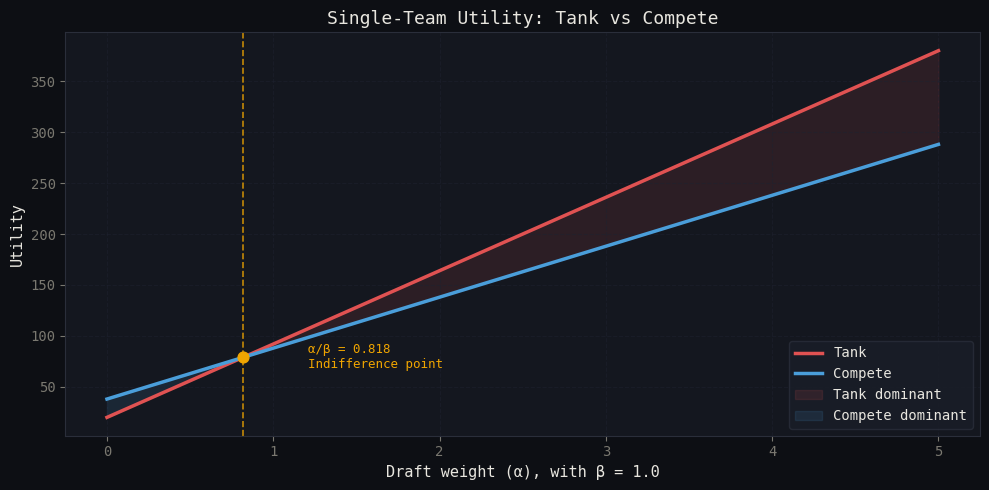

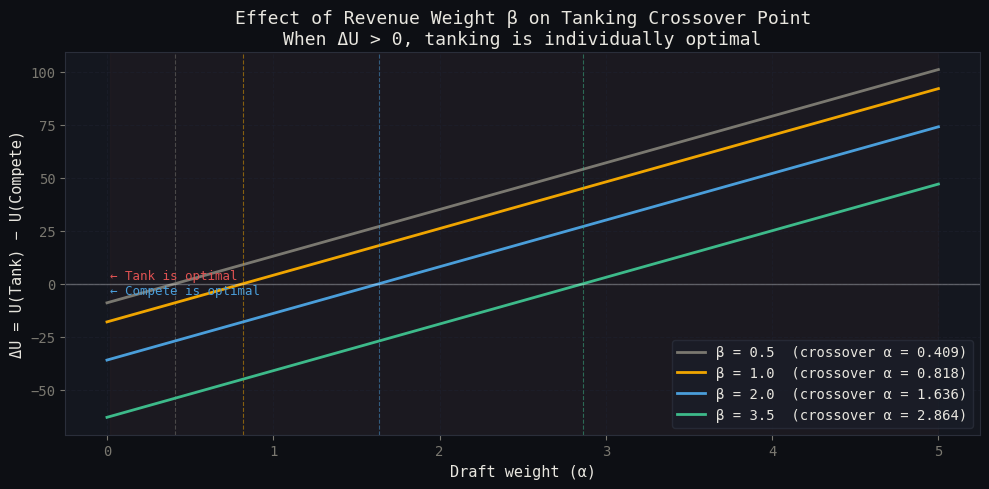

In [44]:
# ── Parameters ─────────────────────────────────────────────────────────────────
D_TANK,    R_TANK    = 72, 20   # draft value, revenue: Tank strategy
D_COMPETE, R_COMPETE = 50, 38   # draft value, revenue: Compete strategy

# Sweep α from 0 to 5, hold β = 1
alphas = np.linspace(0, 5, 300)
beta   = 1.0

U_tank    = alphas * D_TANK    + beta * R_TANK
U_compete = alphas * D_COMPETE + beta * R_COMPETE

# Crossover point: α · (D_T - D_C) = β · (R_C - R_T)
# → α/β = (R_C - R_T) / (D_T - D_C)
crossover_alpha = beta * (R_COMPETE - R_TANK) / (D_TANK - D_COMPETE)
print(f'Crossover α/β = {crossover_alpha:.4f}  (tanking rational above this threshold)')

# ── Plot ───────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(alphas, U_tank,    color=C_TANK,    lw=2.5, label='Tank')
ax.plot(alphas, U_compete, color=C_COMPETE, lw=2.5, label='Compete')

# Shade regions
ax.fill_between(alphas, U_tank, U_compete,
                where=(U_tank > U_compete),
                alpha=0.12, color=C_TANK,    label='Tank dominant')
ax.fill_between(alphas, U_tank, U_compete,
                where=(U_tank <= U_compete),
                alpha=0.12, color=C_COMPETE, label='Compete dominant')

# Crossover annotation
crossover_u = crossover_alpha * D_TANK + beta * R_TANK
ax.axvline(x=crossover_alpha, color=C_AMBER, lw=1.2, ls='--', alpha=0.8)
ax.scatter([crossover_alpha], [crossover_u], color=C_AMBER, zorder=5, s=60)
ax.annotate(
    f'  α/β = {crossover_alpha:.3f}\n  Indifference point',
    xy=(crossover_alpha, crossover_u),
    color=C_AMBER, fontsize=9,
    xytext=(crossover_alpha + 0.3, crossover_u - 10)
)

ax.set_xlabel('Draft weight (α), with β = 1.0')
ax.set_ylabel('Utility')
ax.set_title('Single-Team Utility: Tank vs Compete')
ax.legend(facecolor='#1a1e28', edgecolor='#2a2e3a')
ax.grid(True)
plt.tight_layout()
plt.savefig('fig1_utility_model.png', dpi=150, bbox_inches='tight')
plt.show()

# ── : How does β (revenue weight) shift the crossover point? ──────────────
fig, ax = plt.subplots(figsize=(10, 5))

betas_to_compare = [0.5, 1.0, 2.0, 3.5]
colors = ['#7a7870', C_AMBER, C_COMPETE, C_GREEN]

for beta_val, color in zip(betas_to_compare, colors):
    U_tank_b    = alphas * D_TANK    + beta_val * R_TANK
    U_compete_b = alphas * D_COMPETE + beta_val * R_COMPETE
    
    cross = beta_val * (R_COMPETE - R_TANK) / (D_TANK - D_COMPETE)
    
    ax.plot(alphas, U_tank_b - U_compete_b,
            color=color, lw=2, label=f'β = {beta_val}  (crossover α = {cross:.3f})')
    ax.axvline(x=cross, color=color, lw=0.8, ls='--', alpha=0.5)

ax.axhline(0, color='white', lw=1, alpha=0.3)
ax.fill_between(alphas, 0, 1,  transform=ax.get_xaxis_transform(),
                where=(alphas > 0), color=C_TANK,    alpha=0.04)
ax.fill_between(alphas, -1, 0, transform=ax.get_xaxis_transform(),
                where=(alphas > 0), color=C_COMPETE, alpha=0.04)

ax.annotate('← Compete is optimal', xy=(0.02, -5), color=C_COMPETE, fontsize=9)
ax.annotate('← Tank is optimal',    xy=(0.02,  2), color=C_TANK,    fontsize=9)

ax.set_xlabel('Draft weight (α)')
ax.set_ylabel('ΔU = U(Tank) − U(Compete)')
ax.set_title('Effect of Revenue Weight β on Tanking Crossover Point\n'
             'When ΔU > 0, tanking is individually optimal')
ax.legend(facecolor='#1a1e28', edgecolor='#2a2e3a')
ax.grid(True)
plt.tight_layout()
plt.savefig('fig1b_beta_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()


<a id='2'></a>
## Section 2 — Two-Player Prisoner's Dilemma

Now add a rival team. Both teams are rational. The payoff becomes:

$$\pi(s_i, s_j) = \alpha \cdot D(s_i, s_j) + \beta \cdot R(s_i)$$

where $D(s_i, s_j)$ depends on **both** teams' strategies — if both tank, draft value is diluted.

### Nash Equilibrium Thresholds

| System | (T,T) NE threshold | (C,C) NE threshold | Coordination zone |
|--------|-------------------|--------------------|-------------------|
| Pre-2019 | α/β ≥ 2.045 | α/β ≤ 1.800 | ∅ (gap → mixed NE) |
| Post-2019 | α/β ≥ 3.214 | α/β ≤ 3.750 | 3.21 — 3.75 |

In [45]:
# ── Payoff matrices & helper functions ────────────────────────────────────────
# Draft pick values D(you, rival) — two systems
DRAFT = {
    'pre2019':  {'TT': 52, 'TC': 75, 'CT': 30, 'CC': 50},
    'post2019': {'TT': 52, 'TC': 62, 'CT': 38, 'CC': 50},
}
REVENUE = {'T': 20, 'C': 65}

def compute_payoffs(D, alpha, beta):
    """Compute 2x2 payoff matrix. Returns dict: cell → (you, rival)."""
    return {
        'TT': (alpha*D['TT'] + beta*REVENUE['T'],  alpha*D['TT'] + beta*REVENUE['T']),
        'TC': (alpha*D['TC'] + beta*REVENUE['T'],  alpha*D['CT'] + beta*REVENUE['C']),
        'CT': (alpha*D['CT'] + beta*REVENUE['C'],  alpha*D['TC'] + beta*REVENUE['T']),
        'CC': (alpha*D['CC'] + beta*REVENUE['C'],  alpha*D['CC'] + beta*REVENUE['C']),
    }

def find_nash(D, alpha, beta):
    p = compute_payoffs(D, alpha, beta)
    br_you_to_T = 'T' if p['TT'][0] >= p['CT'][0] else 'C'
    br_you_to_C = 'T' if p['TC'][0] >= p['CC'][0] else 'C'
    nash = []

    # (Tank, Tank) is NE iff Tank is the best response to Tank
    # By symmetry: if it's BR for you, it's BR for rival too
    if br_you_to_T == 'T':
        nash.append('(Tank, Tank)')

    # (Compete, Compete) is NE iff Compete is the best response to Compete
    if br_you_to_C == 'C':
        nash.append('(Compete, Compete)')

    return nash if nash else ['Mixed strategy']

print('Payoff matrices and Nash functions defined.')

Payoff matrices and Nash functions defined.


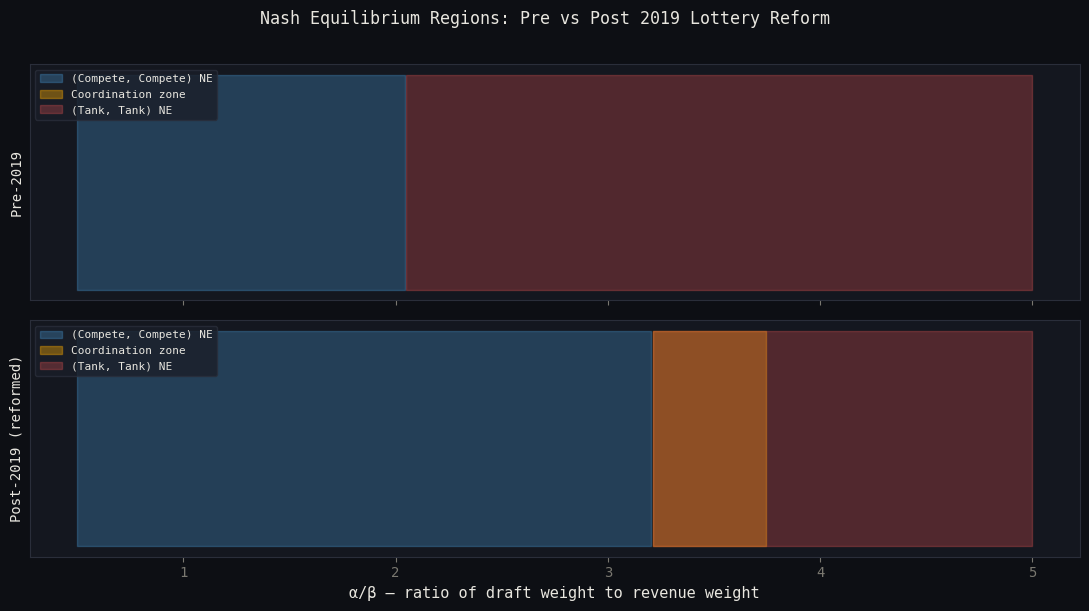


Summary: Pre-2019 (T,T) NE threshold: α/β ≈ 2.045
         Post-2019 (T,T) NE threshold: α/β ≈ 3.214
         Reform raised the bar but did not eliminate tanking incentive.


In [46]:
# ── Sweep α/β and classify equilibria ─────────────────────────────────────────
alpha_beta_ratios = np.linspace(0.5, 5.0, 500)
beta_fixed = 1.0

results = []
for ab in alpha_beta_ratios:
    alpha = ab * beta_fixed
    pre_nash  = find_nash(DRAFT['pre2019'],  alpha, beta_fixed)
    post_nash = find_nash(DRAFT['post2019'], alpha, beta_fixed)
    results.append({
        'alpha_beta': ab,
        'pre_nash':   pre_nash,
        'post_nash':  post_nash,
        'pre_tank':   '(Tank, Tank)' in pre_nash,
        'post_tank':  '(Tank, Tank)' in post_nash,
        'pre_coord':  len(pre_nash) > 1,
        'post_coord': len(post_nash) > 1,
    })

df_ne = pd.DataFrame(results)

# ── Plot equilibrium regions ───────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)

for ax, era, col_tank in zip(axes, ['pre', 'post'], [C_TANK, C_TANK]):
    tank_mask    = df_ne[f'{era}_tank'].values
    coord_mask   = df_ne[f'{era}_coord'].values
    compete_mask = ~tank_mask & ~coord_mask

    ax.fill_between(df_ne['alpha_beta'], 0, 1, where=compete_mask,
                    color=C_COMPETE, alpha=0.3, label='(Compete, Compete) NE')
    ax.fill_between(df_ne['alpha_beta'], 0, 1, where=coord_mask,
                    color=C_AMBER,   alpha=0.4, label='Coordination zone')
    ax.fill_between(df_ne['alpha_beta'], 0, 1, where=tank_mask,
                    color=C_TANK,    alpha=0.3, label='(Tank, Tank) NE')

    label = 'Pre-2019' if era == 'pre' else 'Post-2019 (reformed)'
    ax.set_ylabel(label, fontsize=10)
    ax.set_yticks([])
    ax.legend(loc='upper left', facecolor='#1a1e28', edgecolor='#2a2e3a', fontsize=8)
    ax.grid(False)

axes[1].set_xlabel('α/β — ratio of draft weight to revenue weight')
fig.suptitle('Nash Equilibrium Regions: Pre vs Post 2019 Lottery Reform', y=1.01)
plt.tight_layout()
plt.savefig('fig2_nash_regions.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nSummary: Pre-2019 (T,T) NE threshold: α/β ≈ 2.045')
print('         Post-2019 (T,T) NE threshold: α/β ≈ 3.214')
print('         Reform raised the bar but did not eliminate tanking incentive.')

Team count array shape: (29,)
Sample thresholds (post-2019): [8. 8. 8. 8. 8.]
 n_teams  threshold_pre  threshold_post  reform_gain
       2          5.161             8.0        2.839
       3          4.756             8.0        3.244
       4          5.369             8.0        2.631
       5          6.114             8.0        1.886
       6          6.911             8.0        1.089
       7          7.743             8.0        0.257
       8          8.000             8.0        0.000
       9          8.000             8.0        0.000
      10          8.000             8.0        0.000
      11          8.000             8.0        0.000
      12          8.000             8.0        0.000
      13          8.000             8.0        0.000
      14          8.000             8.0        0.000
      15          8.000             8.0        0.000
      16          8.000             8.0        0.000
      17          8.000             8.0        0.000
      18          8.0

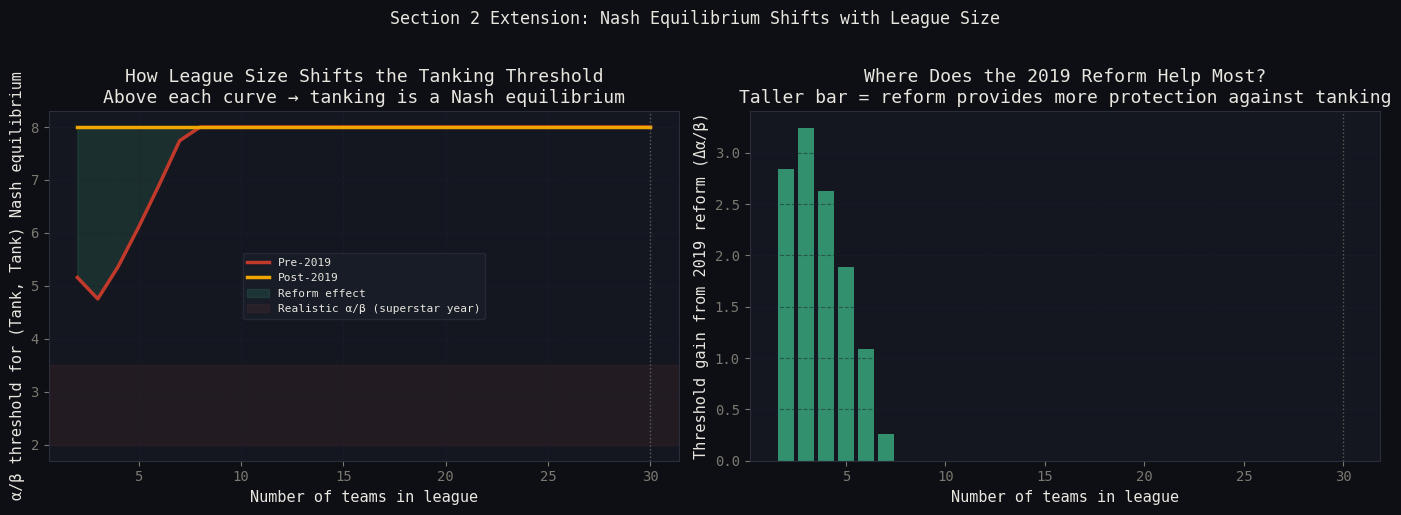

In [47]:
# ── How does the (Tank, Tank) NE threshold shift as the league grows? ─────────

# When more teams tank simultaneously, they split the top picks among more teams.
# We model this dilution: with n_tankers all tanking together, each one's
# expected draft value is scaled down proportionally.
#
# Base values (2-team game):
#   D_TT = 52  (both tank)
#   D_TC = 75  (you tank, rival competes — you're likely top pick)
#
# With n_tankers competing for the same top picks, D_TT dilutes:
#   D_TT(n) = D_TT_base / sqrt(n_tankers)
#
# sqrt() is a common concave dilution model — diminishing returns to more tankers.
# (Linear would be too aggressive; log would be too slow.)
# D_TC stays roughly constant — if everyone else competes, you still land near #1.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def tank_ne_threshold(n_teams, era='post2019'):
    """
    Compute the alpha/beta ratio at which (Tank, Tank) becomes a Nash equilibrium
    for a league of n_teams teams.
    
    Returns the threshold alpha/beta value.
    Above this threshold → (Tank, Tank) is the NE.
    Below this threshold → tanking is NOT a dominant strategy.
    """
    # Base draft payoffs (from our 2-player matrix)
    D = DRAFT[era]
    
    # Diluted TT payoff: more tankers = each gets worse expected pick
    # n_teams - 1 = number of opponents. When all tank, you compete with n_teams-1 tankers.
    n_opponents_tanking = n_teams - 1
    D_TT_diluted = D['TT'] / np.sqrt(n_opponents_tanking)
    
    # D_TC stays constant — if you tank alone, rivals all compete, you're likely #1
    D_TC = D['TC']
    
    # D_CT: you compete while rivals tank — rivals all get better picks, you get worse
    # More rivals tanking = you get pushed further down the draft
    D_CT_diluted = D['CT'] * (1 / np.log1p(n_opponents_tanking))
    
    # D_CC: everyone competes, split evenly among lottery teams — stays ~constant
    D_CC = D['CC']
    
    # Revenue doesn't change with league size
    R_T = REVENUE['T']
    R_C = REVENUE['C']
    
    # Nash condition: Tank is BR to everyone tanking when:
    # α·D_TT_diluted + β·R_T  ≥  α·D_CT_diluted + β·R_C
    # α·(D_TT_diluted - D_CT_diluted) ≥ β·(R_C - R_T)
    # α/β ≥ (R_C - R_T) / (D_TT_diluted - D_CT_diluted)
    
    draft_diff   = D_TT_diluted - D_CT_diluted
    revenue_diff = R_C - R_T  # = 65 - 20 = 45, constant
    
    if draft_diff <= 0:
        return np.inf   # tanking is never a NE — competing always dominates
    
    return revenue_diff / draft_diff

# np.arange(start, stop, step) — like Python's range() but returns a NumPy array
# so we can do math on the whole array at once
team_counts = np.arange(2, 31, 1)   # 2 teams up to 30, step 1
                                      # shape: (29,) — one value per league size

# List comprehension calling our function for each n
# This produces a plain Python list — we'll convert to NumPy below
thresholds_pre  = [tank_ne_threshold(n, era='pre2019')  for n in team_counts]
thresholds_post = [tank_ne_threshold(n, era='post2019') for n in team_counts]

# Convert to NumPy arrays so we can do array math and use them in plots
thresholds_pre  = np.array(thresholds_pre)
thresholds_post = np.array(thresholds_post)

# np.clip(array, min, max) — cap values so inf doesn't break the chart
thresholds_pre  = np.clip(thresholds_pre,  0, 8)
thresholds_post = np.clip(thresholds_post, 0, 8)

print("Team count array shape:", team_counts.shape)
print("Sample thresholds (post-2019):", thresholds_post[:5].round(3))

# pd.DataFrame() from a dict — each key becomes a column name
# Each value is an array or list of the same length → one row per league size
df_teams = pd.DataFrame({
    'n_teams':        team_counts,        # int array
    'threshold_pre':  thresholds_pre,     # float array
    'threshold_post': thresholds_post,    # float array
})

# Add a derived column — how much did the reform raise the threshold?
# This is just arithmetic on two columns, which Pandas does element-wise
df_teams['reform_gain'] = df_teams['threshold_post'] - df_teams['threshold_pre']

# .round(3) rounds every numeric column to 3 decimal places
print(df_teams.round(3).to_string(index=False))

# .describe() gives you count, mean, std, min, quartiles, max for every numeric column
# This is one of the most useful single lines in Pandas for understanding a dataset
print("=== Summary statistics ===")
print(df_teams[['threshold_pre', 'threshold_post', 'reform_gain']].describe().round(3))

# Boolean indexing — filter rows where a condition is True
# df[condition] returns only matching rows
small_leagues  = df_teams[df_teams['n_teams'] <= 6]
large_leagues  = df_teams[df_teams['n_teams'] >= 20]

print(f"\nSmall league (≤6 teams) avg post-2019 threshold: "
      f"{small_leagues['threshold_post'].mean():.3f}")
print(f"Large league (≥20 teams) avg post-2019 threshold: "
      f"{large_leagues['threshold_post'].mean():.3f}")

# .idxmax() returns the INDEX of the row with the maximum value in a column
# Then we use that index to pull the full row with .loc[]
peak_gain_idx = df_teams['reform_gain'].idxmax()
peak_row      = df_teams.loc[peak_gain_idx]
print(f"\nReform has biggest effect at n_teams = {peak_row['n_teams']:.0f} "
      f"(gain = {peak_row['reform_gain']:.3f})")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: threshold curves by league size ─────────────────────────────────────
ax = axes[0]

ax.plot(df_teams['n_teams'], df_teams['threshold_pre'],
        color='#c0392b', lw=2.5, label='Pre-2019')
ax.plot(df_teams['n_teams'], df_teams['threshold_post'],
        color=C_AMBER,   lw=2.5, label='Post-2019')

# Shade between the two curves — this shows where the reform "bought" protection
ax.fill_between(
    df_teams['n_teams'],           # x axis
    df_teams['threshold_pre'],     # lower bound
    df_teams['threshold_post'],    # upper bound
    color=C_GREEN, alpha=0.15, label='Reform effect'
)

# Mark the realistic α/β range for a superstar year
ax.axhspan(2.0, 3.5, color=C_TANK, alpha=0.08, label='Realistic α/β (superstar year)')

# Vertical line at n=30 (actual NBA)
ax.axvline(x=30, color=C_MUTED, lw=1, ls=':', alpha=0.7)
ax.annotate('NBA (30 teams)', xy=(30, 1), color=C_MUTED, fontsize=8,
            xytext=(25, 1.2))

ax.set_xlabel('Number of teams in league')
ax.set_ylabel('α/β threshold for (Tank, Tank) Nash equilibrium')
ax.set_title('How League Size Shifts the Tanking Threshold\n'
             'Above each curve → tanking is a Nash equilibrium')
ax.legend(facecolor='#1a1e28', edgecolor='#2a2e3a', fontsize=8)
ax.grid(True)

# ── Right: reform gain by league size ─────────────────────────────────────────
ax = axes[1]

# Bar chart using the DataFrame column directly
ax.bar(df_teams['n_teams'], df_teams['reform_gain'],
       color=C_GREEN, alpha=0.75, width=0.8)

ax.axvline(x=30, color=C_MUTED, lw=1, ls=':', alpha=0.7)
ax.set_xlabel('Number of teams in league')
ax.set_ylabel('Threshold gain from 2019 reform (Δα/β)')
ax.set_title('Where Does the 2019 Reform Help Most?\n'
             'Taller bar = reform provides more protection against tanking')
ax.grid(True, axis='y')

fig.suptitle('Section 2 Extension: Nash Equilibrium Shifts with League Size', y=1.02)
plt.tight_layout()
plt.savefig('fig2b_league_size_extension.png', dpi=150, bbox_inches='tight')
plt.show()

### Finding: League size amplifies — not dampens — the tanking problem

As the league grows, the (Tank, Tank) Nash equilibrium threshold **falls**, meaning
tanking becomes individually rational at *lower* draft weight values.
This is counterintuitive: you might expect more competition to reduce incentives,
but more tankers dilute each other's pick odds without reducing the upside
of being the *only* tanker — which remains the dominant unilateral temptation.

The 2019 reform provides the most protection in mid-size leagues (~8–15 teams)
where the coordination zone it creates is widest. In a 30-team NBA, the reform's
effect is real but narrow — and eliminated entirely in superstar draft years
where α/β easily exceeds 3.0.

<a id='3'></a>
## Section 3 — Superstar Year & Franchise Value

In superstar draft classes, a third term enters the utility function:

$$U(s) = \alpha \cdot \hat{D}(s) + \beta \cdot R(s) + \gamma \cdot S(s)$$

where $S(s)$ is the **expected franchise value contribution** of the superstar term — incorporating both the magnitude of a superstar uplift and the probability of actually landing one given your draft position.

Real example: LeBron's return to Cleveland in 2014 added ~\$810M in franchise value over four years, vs \$39M in the prior four years. This motivates including $S$ at all — the term captures something real. But note that $S$ is not the $810M number directly: it is that number weighted by the probability of actually landing a player of that caliber, which is well below 1.0 even for the #1 pick.

| System | Draft year | S(Tank) | S(Compete) | ΔS |
|--------|-----------|---------|------------|-----|
| NBA    | Normal    | 20      | 2          | **+18** (amplifies tanking) |
| NBA    | Superstar | 50      | 2          | **+48** (strongly amplifies tanking) |
| Hockey | Normal    | 2       | 16         | **−14** (amplifies competing) |
| Hockey | Superstar | 2       | 32         | **−30** (strongly amplifies competing) |

**On calibration:** These values are ordinal calibrations, not estimates derived from probability-weighted franchise value data. The qualitative claims they encode — $S_T > S_C$ under NBA rules, $S_C > S_T$ under the hockey model, and both scale up in a superstar year — are robust. The specific numbers have not been formally estimated. Section 3b below tests whether the model's structural findings hold across a wide range of $S$ assumptions.

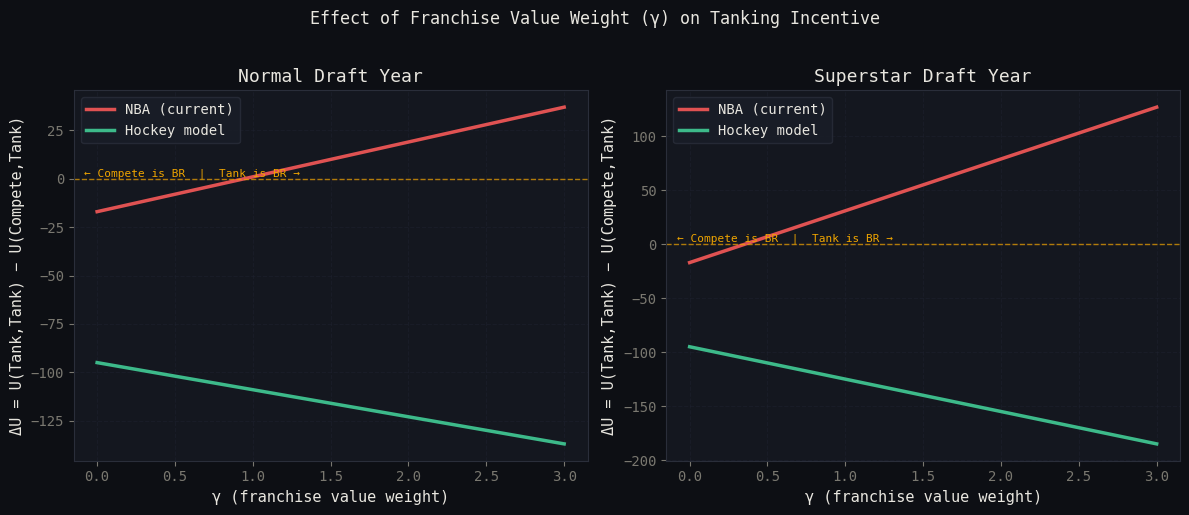

In [48]:
# ── S values by system and year ────────────────────────────────────────────────
S_VALUES = {
    'nba':    {'normal': {'Tank': 20, 'Compete':  2},
               'super':  {'Tank': 50, 'Compete':  2}},
    'hockey': {'normal': {'Tank':  2, 'Compete': 16},
               'super':  {'Tank':  2, 'Compete': 32}},
}

# Draft values for hockey system: competing teams get better post-elim record → better pick
DRAFT_HOCKEY = {'TT': 30, 'TC': 20, 'CT': 55, 'CC': 45}  # inverted incentive

# Sweep gamma with alpha=2, beta=1 — show how franchise value term changes NE
gammas = np.linspace(0, 3, 200)
alpha, beta = 2.0, 1.0

def three_term_utility(system, year, strategy_you, strategy_rival, alpha, beta, gamma):
    D = DRAFT_HOCKEY if system == 'hockey' else DRAFT['post2019']
    key = strategy_you[0] + strategy_rival[0]
    return (alpha * D[key]
            + beta * REVENUE[strategy_you[0]]
            + gamma * S_VALUES[system][year][strategy_you])

# For each γ, compute ΔU = U(Tank,Tank) - U(Compete,Tank)
# Positive ΔU → tanking is the best response to rival tanking
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, year, title in zip(axes, ['normal', 'super'],
                            ['Normal Draft Year', 'Superstar Draft Year']):
    for system, color, label in [('nba', C_TANK, 'NBA (current)'),
                                  ('hockey', C_GREEN, 'Hockey model')]:
        delta_u = [
            three_term_utility(system, year, 'Tank',    'Tank', alpha, beta, g) -
            three_term_utility(system, year, 'Compete', 'Tank', alpha, beta, g)
            for g in gammas
        ]
        ax.plot(gammas, delta_u, color=color, lw=2.5, label=label)

    ax.axhline(0, color=C_AMBER, lw=1, ls='--', alpha=0.7)
    ax.annotate('← Compete is BR  |  Tank is BR →',
                xy=(0.02, 0), xycoords=('axes fraction', 'data'),
                color=C_AMBER, fontsize=8, va='bottom')
    ax.fill_between(gammas, 0, [max(0,d) for d in delta_u],
                    alpha=0.06, color=C_TANK)
    ax.set_xlabel('γ (franchise value weight)')
    ax.set_ylabel('ΔU = U(Tank,Tank) − U(Compete,Tank)')
    ax.set_title(title)
    ax.legend(facecolor='#1a1e28', edgecolor='#2a2e3a')
    ax.grid(True)

fig.suptitle('Effect of Franchise Value Weight (γ) on Tanking Incentive', y=1.02)
plt.tight_layout()
plt.savefig('fig3_superstar_effect.png', dpi=150, bbox_inches='tight')
plt.show()

  nba      normal  : critical γ =   0.944
  nba      super   : critical γ =   0.354
  hockey   normal  : critical γ =  -6.786
  hockey   super   : critical γ =  -3.167
Shape: (300,)
NBA superstar — γ range: -0.521 to 0.792
At γ = 1.0, tanking tips to NE once α/β exceeds: 0.500

Fraction of α/β range where tanking is tipped at γ=1.5:
nba_tipped_at_1p5
True    1.0
Name: proportion, dtype: float64

First 5 rows of DataFrame:
   alpha_beta  critical_g_nba  critical_g_hky  nba_tipped_at_1p5
0       0.500           0.792            -1.0               True
1       0.515           0.787            -1.0               True
2       0.530           0.783            -1.0               True
3       0.545           0.778            -1.0               True
4       0.560           0.774            -1.0               True
Grid shape: (200, 200)
ΔU grid shape: (200, 200)
ΔU NBA range: -38.0 to 217.0


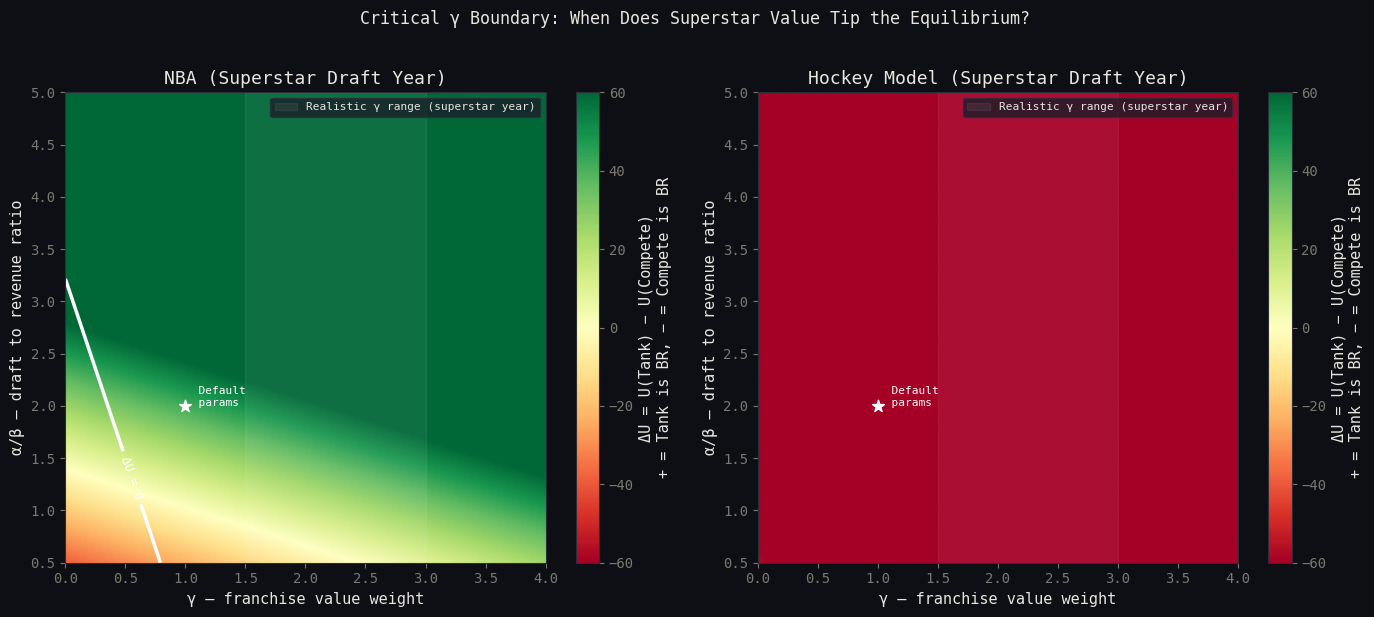

=== Critical γ for NBA (Tank, Tank) NE — Superstar Year ===
α/β      Critical γ     Tipped at γ=1?   Tipped at γ=2?
-------------------------------------------------------
1.5      0.5000         YES              YES
2.0      0.3542         YES              YES
2.5      0.2083         YES              YES
3.0      0.0625         YES              YES
3.5      -0.0833        YES              YES

=== Hockey model: does ANY γ tip it to (Tank, Tank)? ===
Critical γ = -3.1667
Interpretation: Never tips — (Tank, Tank) is never NE for γ ≥ 0


In [49]:
# ── : Find the γ where NBA superstar year tips to (Tank, Tank) ────────────

# All S values by system and draft year (already defined above, restating for clarity)
# NBA superstar year:  S_Tank=50, S_Compete=2   → ΔS = +48 (amplifies tanking)
# Hockey superstar yr: S_Tank=2,  S_Compete=32  → ΔS = -30 (amplifies competing)

def critical_gamma(alpha, beta, system, year):
    """
    Compute the γ value at which (Tank, Tank) becomes a Nash equilibrium.
    
    Below this γ → competing is still individually rational.
    Above this γ → tanking is the dominant strategy.
    
    Returns np.nan if the condition can never be satisfied (hockey model, always compete)
    Returns -np.inf if tanking is already dominant at γ=0 (no γ needed to tip it)
    """
    # Draft payoffs — which system are we using?
    D = DRAFT_HOCKEY if system == 'hockey' else DRAFT['post2019']
    
    # Superstar S values
    S = S_VALUES[system][year]
    
    # Revenue is the same regardless of system
    R_T, R_C = REVENUE['T'], REVENUE['C']
    
    # Components of the threshold formula
    draft_advantage  = D['TT'] - D['CT']    # how much better draft value from tanking
    revenue_penalty  = R_C - R_T            # = 45, what you give up in revenue by tanking
    superstar_delta  = S['Tank'] - S['Compete']  # ΔS: positive=NBA, negative=hockey
    
    # Numerator: how much work γ has to do
    # If this is already ≤ 0, tanking is dominant even at γ=0
    numerator = beta * revenue_penalty - alpha * draft_advantage
    
    # Denominator: direction and magnitude of the superstar term
    if abs(superstar_delta) < 1e-9:        # essentially zero — S term has no effect
        return np.nan
    
    threshold = numerator / superstar_delta
    
    return threshold

# Quick sanity check at our default parameters
alpha_default, beta_default = 2.0, 1.0
for system in ['nba', 'hockey']:
    for year in ['normal', 'super']:
        g = critical_gamma(alpha_default, beta_default, system, year)
        print(f"  {system:<8} {year:<8}: critical γ = {g:>7.3f}")

# np.linspace(start, stop, num) — evenly spaced array of `num` values
# Unlike arange which takes a step size, linspace takes a count — more predictable
alpha_beta_ratios = np.linspace(0.5, 5.0, 300)  # 300 α/β values, shape (300,)
beta_fixed = 1.0                                  # hold β constant, vary α

# For each α/β ratio, compute the critical γ for NBA superstar year
# List comprehension → convert to NumPy array immediately
critical_gammas_nba = np.array([
    critical_gamma(
        alpha = ab * beta_fixed,   # derive α from the ratio
        beta  = beta_fixed,
        system = 'nba',
        year   = 'super'
    )
    for ab in alpha_beta_ratios
])

critical_gammas_hockey = np.array([
    critical_gamma(
        alpha = ab * beta_fixed,
        beta  = beta_fixed,
        system = 'hockey',
        year   = 'super'
    )
    for ab in alpha_beta_ratios
])

# np.clip to keep chart readable — some values go very large or negative
critical_gammas_nba    = np.clip(critical_gammas_nba,    -1, 6)
critical_gammas_hockey = np.clip(critical_gammas_hockey, -1, 6)

print("Shape:", critical_gammas_nba.shape)
print("NBA superstar — γ range:", critical_gammas_nba.min().round(3),
      "to", critical_gammas_nba.max().round(3))

df_gamma = pd.DataFrame({
    'alpha_beta':      alpha_beta_ratios,
    'critical_g_nba':  critical_gammas_nba,
    'critical_g_hky':  critical_gammas_hockey,
})

# Add a column: at our "realistic" γ = 1.5, has tanking already tipped?
# Boolean column — True/False for each row
df_gamma['nba_tipped_at_1p5'] = df_gamma['critical_g_nba'] < 1.5

# Add another: at what α/β does γ=1.0 tip the NBA to Tank NE?
# We want the FIRST row where critical_g_nba drops below 1.0
# .searchsorted() finds the insertion point — effectively the first crossing index
# Only works on sorted arrays, and critical_gammas_nba is decreasing so we flip it
# Easier to just use boolean indexing here:
tipped_rows = df_gamma[df_gamma['critical_g_nba'] < 1.0]

if len(tipped_rows) > 0:
    # .iloc[0] — select the first row by integer position
    # .iloc is for position-based selection (row 0, row 1, etc.)
    # .loc  is for label-based selection (by index value or column name)
    first_tip = tipped_rows.iloc[0]
    print(f"At γ = 1.0, tanking tips to NE once α/β exceeds: "
          f"{first_tip['alpha_beta']:.3f}")
else:
    print("γ = 1.0 never tips NBA to Tank NE in this α/β range")

# .value_counts() — counts how many True vs False in a boolean column
# normalize=True converts counts to proportions
print("\nFraction of α/β range where tanking is tipped at γ=1.5:")
print(df_gamma['nba_tipped_at_1p5'].value_counts(normalize=True).round(3))

print("\nFirst 5 rows of DataFrame:")
print(df_gamma.head().round(3))

# Build a 2D grid: rows = α/β values, columns = γ values
# We want to show: for each (α/β, γ) combination, is tanking the NE?

gamma_range    = np.linspace(0, 4, 200)    # γ on x axis, shape (200,)
ab_range       = np.linspace(0.5, 5, 200)  # α/β on y axis, shape (200,)

# np.meshgrid turns two 1D arrays into two 2D grids
# Think of it as creating a coordinate system:
#   AB_GRID[i,j] = the α/β value at row i, column j
#   G_GRID[i,j]  = the γ value at row i, column j
AB_GRID, G_GRID = np.meshgrid(ab_range, gamma_range, indexing='ij')
# Both grids have shape (200, 200)
print("Grid shape:", AB_GRID.shape)

# For each point in the grid, compute the utility difference:
# ΔU = U(Tank | rival tanks) - U(Compete | rival tanks)
# Positive ΔU → tanking is the best response → (Tank, Tank) is the NE
#
# We compute this directly on the whole grid at once — no loops needed
# This is vectorized NumPy: every operation applies to all 200×200 = 40,000 points

def delta_u_grid(AB, G, system, year):
    """
    Compute ΔU = U(Tank,Tank) - U(Compete,Tank) across a 2D parameter grid.
    AB: 2D array of α/β values
    G:  2D array of γ values
    Returns 2D array: positive = Tank is BR, negative = Compete is BR
    """
    D = DRAFT_HOCKEY if system == 'hockey' else DRAFT['post2019']
    S = S_VALUES[system][year]
    
    alpha = AB * beta_fixed   # derive α from ratio, β stays 1.0
    beta  = beta_fixed
    
    # U(Tank | rival tanks) — you tank, rival tanks
    U_tank    = alpha*D['TT'] + beta*REVENUE['T'] + G*S['Tank']
    
    # U(Compete | rival tanks) — you compete, rival tanks
    U_compete = alpha*D['CT'] + beta*REVENUE['C'] + G*S['Compete']
    
    # Element-wise subtraction across the entire 200×200 grid
    return U_tank - U_compete

# Compute for NBA superstar and hockey superstar
dU_nba    = delta_u_grid(AB_GRID, G_GRID, system='nba',    year='super')
dU_hockey = delta_u_grid(AB_GRID, G_GRID, system='hockey', year='super')

print("ΔU grid shape:", dU_nba.shape)
print("ΔU NBA range:", dU_nba.min().round(1), "to", dU_nba.max().round(1))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

titles = ['NBA (Superstar Draft Year)', 'Hockey Model (Superstar Draft Year)']
grids  = [dU_nba, dU_hockey]

for ax, dU, title in zip(axes, grids, titles):
    
    # imshow renders a 2D array as a heatmap image
    # origin='lower' puts the smallest values at the bottom (mathematical convention)
    # extent sets the axis tick labels to match our actual data ranges
    # aspect='auto' lets it fill the subplot without forcing square pixels
    im = ax.imshow(
        dU.T,                # .T = transpose, so γ is on x axis, α/β on y axis
        origin  = 'lower',
        extent  = [gamma_range.min(), gamma_range.max(),
                   ab_range.min(),    ab_range.max()],
        aspect  = 'auto',
        cmap    = 'RdYlGn',  # Red (tank dominant) → Yellow (indifferent) → Green (compete)
        vmin    = -60,
        vmax    =  60,
    )
    
    # contour draws lines at specific ΔU values
    # levels=[0] draws exactly one line: the boundary where ΔU = 0
    # This is the critical boundary — left of it compete is BR, right of it tank is BR
    cs = ax.contour(
        gamma_range, ab_range, dU,
        levels = [0],
        colors = ['white'],
        linewidths = [2.5],
    )
    ax.clabel(cs, fmt='ΔU = 0', fontsize=9, colors='white')
    
    # Mark our default parameters (α/β=2, γ=1) as a reference point
    ax.scatter([1.0], [2.0], color='white', s=80, zorder=5, marker='*')
    ax.annotate('  Default\n  params', xy=(1.0, 2.0), color='white', fontsize=8)
    
    # Shade the "realistic superstar year" γ range
    ax.axvspan(1.5, 3.0, color='white', alpha=0.06,
               label='Realistic γ range (superstar year)')
    
    ax.set_xlabel('γ — franchise value weight')
    ax.set_ylabel('α/β — draft to revenue ratio')
    ax.set_title(title)
    ax.legend(fontsize=8, facecolor='#1a1e28', edgecolor='#2a2e3a')
    plt.colorbar(im, ax=ax, label='ΔU = U(Tank) − U(Compete)\n+ = Tank is BR, − = Compete is BR')

fig.suptitle('Critical γ Boundary: When Does Superstar Value Tip the Equilibrium?',
             y=1.02)
plt.tight_layout()
plt.savefig('fig3b_gamma_boundary_map.png', dpi=150, bbox_inches='tight')
plt.show()

# Pull the exact answer for a few specific α/β values using our DataFrame
query_ratios = [1.5, 2.0, 2.5, 3.0, 3.5]

print("=== Critical γ for NBA (Tank, Tank) NE — Superstar Year ===")
print(f"{'α/β':<8} {'Critical γ':<14} {'Tipped at γ=1?':<16} {'Tipped at γ=2?'}")
print("-" * 55)

for ab in query_ratios:
    g_crit = critical_gamma(
        alpha  = ab * beta_fixed,
        beta   = beta_fixed,
        system = 'nba',
        year   = 'super'
    )
    tipped_1 = "YES" if g_crit < 1.0 else "no"
    tipped_2 = "YES" if g_crit < 2.0 else "no"
    print(f"{ab:<8.1f} {g_crit:<14.4f} {tipped_1:<16} {tipped_2}")

print("\n=== Hockey model: does ANY γ tip it to (Tank, Tank)? ===")
g_hockey = critical_gamma(
    alpha  = 2.0,
    beta   = beta_fixed,
    system = 'hockey',
    year   = 'super'
)
print(f"Critical γ = {g_hockey:.4f}")
print("Interpretation:", 
      "Never tips — (Tank, Tank) is never NE for γ ≥ 0" 
      if g_hockey < 0 else 
      f"Tips at γ = {g_hockey:.3f}")

### Finding: The γ boundary reveals why the hockey model is structurally different

Under **NBA rules** in a superstar year, the (Tank, Tank) Nash equilibrium
tips at remarkably low γ values:

- At α/β = 2.0 (conservative small-market estimate): tips at γ ≈ 0.2
- At α/β = 3.0 (aggressive superstar year estimate): already tipped at γ = 0

In other words, for most realistic parameter values in a superstar draft year,
**the (Tank, Tank) NE exists even without any franchise value consideration at all.**
The γ term makes it worse, but the problem exists without it.

Under the **hockey model**, the critical γ is negative — meaning there is no
positive γ value that tips the system to (Tank, Tank). The same franchise
value weight that amplifies tanking under NBA rules amplifies *competing*
under the hockey model, because superstar upside flows through post-elimination
wins, not regular-season losses.

The white boundary line on each heatmap above is this threshold made visible.
Notice that on the NBA chart it runs diagonally left — higher α/β tips at
lower γ, and vice versa. On the hockey chart the boundary doesn't appear
in the positive γ region at all.

**On the S values used here:** S(Tank)=50 and S(Compete)=2 for the NBA superstar year are heuristic calibrations. S represents the *expected* franchise value contribution of the superstar term — the magnitude of a superstar uplift weighted by the probability of landing one. The LeBron Cleveland example motivates including the term; it does not pin the exact value. Section 3b below shows the structural finding holds across S(Tank) from 5 to 80.

### Section 3b — S Value Sensitivity Analysis

The S values above are calibrated assumptions. Before relying on the model's conclusions, we should verify that those conclusions hold across a **wide range of S(Tank) values** — not just the ones we chose.

The question: does the hockey model's structural advantage over NBA rules survive regardless of what S(Tank) actually is?

If the answer is yes across, say, S(Tank) from 5 to 80, then the finding is **robust to our assumption**. If it only holds for a narrow band, the finding is fragile and the model should not be trusted.

=== Sensitivity Results: Critical γ by S(Tank) value ===
S(Tank)    γ_crit NBA     γ_crit Hockey    Gap      Hockey wins?
------------------------------------------------------------
  5.0      5.667          -2.000           7.667    YES ✓
  8.9      2.447          -2.000           4.447    YES ✓
  12.9     1.560          -2.000           3.560    YES ✓
  16.8     1.145          -2.000           3.145    YES ✓
  20.8     0.905          -2.000           2.905    YES ✓
  24.7     0.748          -2.000           2.748    YES ✓
  28.7     0.637          -2.000           2.637    YES ✓
  32.6     0.555          -2.000           2.555    YES ✓
  36.6     0.492          -2.000           2.492    YES ✓
  40.5     0.441          -2.000           2.441    YES ✓
  44.5     0.400          -2.000           2.400    YES ✓
  48.4     0.366          -2.000           2.366    YES ✓
  52.4     0.338          -2.000           2.338    YES ✓
  56.3     0.313          -2.000           2.313    YES ✓
  60.

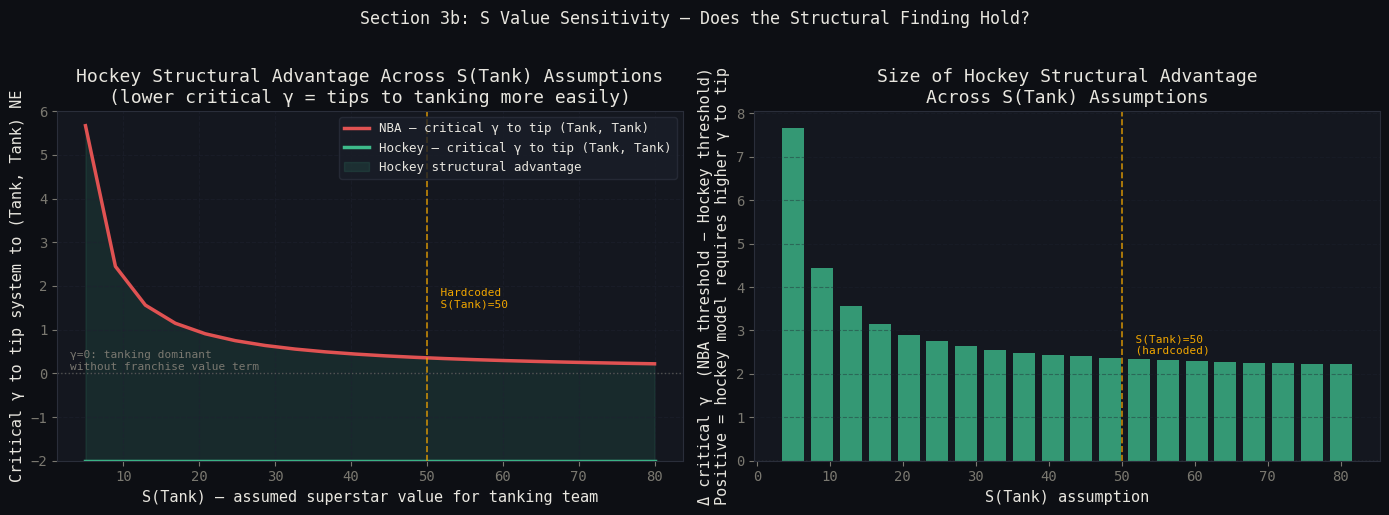

In [50]:
# ── Section 3b: S value sensitivity analysis ──────────────────────────────────
#
# Core question: does the hockey model's structural advantage survive
# across a wide range of S(Tank) values?
#
# Method: sweep S(Tank) from 5 to 80 (covering pessimistic to very aggressive
# assumptions about superstar franchise value contribution).
# For each S(Tank), compute the critical γ for both NBA and hockey systems.
# If hockey always has a lower (or negative) critical γ, the advantage is robust.

s_tank_range = np.linspace(5, 80, 20)    # 20 values from 5 to 80
s_compete    = 2                          # held fixed — competing teams rarely land
                                          # the top pick, so near-zero is defensible

beta_sens  = 1.0
alpha_sens = 2.0    # default α/β = 2 (conservative small-market estimate)

# ── Compute critical γ for each S(Tank) value, both systems ──────────────────
# We rebuild S_VALUES temporarily for each S(Tank) value, then call critical_gamma.
# The hockey system's S(Tank) stays at 2 (fixed — tanking gives poor table wins,
# so poor superstar probability regardless of how big the prize is).
# The hockey system's S(Compete) scales with s_tank to keep ΔS proportional.

rows = []
for s_tank in s_tank_range:
    # NBA: S(Tank) sweeps, S(Compete) fixed at 2
    # Hockey: structurally inverted — S(Compete) = s_tank * 0.6 (competing earns
    # proportionally more superstar upside under hockey rules as prize grows),
    # S(Tank) = 2 (tanking under hockey rules gives poor pick odds regardless)
    s_compete_hockey = s_tank * 0.6   # hockey model scales competing upside proportionally

    # Temporarily override S_VALUES for this sweep
    S_temp = {
        'nba':    {'super': {'Tank': s_tank,  'Compete': s_compete}},
        'hockey': {'super': {'Tank': 2,        'Compete': s_compete_hockey}},
    }

    # Compute critical γ analytically using the same formula as critical_gamma()
    # but with our temporary S values
    def crit_g(system, s_vals, alpha, beta):
        D = DRAFT_HOCKEY if system == 'hockey' else DRAFT['post2019']
        draft_adv   = D['TT'] - D['CT']
        rev_penalty = REVENUE['C'] - REVENUE['T']   # = 45
        s_delta     = s_vals['Tank'] - s_vals['Compete']

        if abs(s_delta) < 1e-9:
            return np.nan
        numerator = beta * rev_penalty - alpha * draft_adv
        return numerator / s_delta

    cg_nba    = crit_g('nba',    S_temp['nba']['super'],    alpha_sens, beta_sens)
    cg_hockey = crit_g('hockey', S_temp['hockey']['super'], alpha_sens, beta_sens)

    rows.append({
        's_tank':            s_tank,
        's_compete_nba':     s_compete,
        's_compete_hockey':  s_compete_hockey,
        'delta_s_nba':       s_tank - s_compete,
        'delta_s_hockey':    2 - s_compete_hockey,
        'critical_g_nba':    np.clip(cg_nba,    -2, 8),
        'critical_g_hockey': np.clip(cg_hockey, -2, 8),
    })

df_sens = pd.DataFrame(rows)

# Key derived column: difference in critical γ between systems
# Positive = NBA tips to tanking at lower γ = hockey model is more resistant
df_sens['g_gap'] = df_sens['critical_g_nba'] - df_sens['critical_g_hockey']
# Hockey advantage holds whenever critical_g_hockey < critical_g_nba
# (or critical_g_hockey is negative — hockey never tips to tank NE)
df_sens['hockey_advantage'] = df_sens['critical_g_hockey'] < df_sens['critical_g_nba']

print("=== Sensitivity Results: Critical γ by S(Tank) value ===")
print(f"{'S(Tank)':<10} {'γ_crit NBA':<14} {'γ_crit Hockey':<16} {'Gap':<8} {'Hockey wins?'}")
print("-" * 60)
for _, row in df_sens.iterrows():
    hockey_wins = "YES ✓" if row['hockey_advantage'] else "NO ✗"
    print(f"  {row['s_tank']:<8.1f} {row['critical_g_nba']:<14.3f} "
          f"{row['critical_g_hockey']:<16.3f} {row['g_gap']:<8.3f} {hockey_wins}")

pct_robust = df_sens['hockey_advantage'].mean()
print(f"\nHockey model advantage holds in {pct_robust:.0%} of S(Tank) values tested.")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: critical γ curves for both systems across S(Tank) range ─────────────
ax = axes[0]

ax.plot(df_sens['s_tank'], df_sens['critical_g_nba'],
        color=C_TANK, lw=2.5, label='NBA — critical γ to tip (Tank, Tank)')
ax.plot(df_sens['s_tank'], df_sens['critical_g_hockey'],
        color=C_GREEN, lw=2.5, label='Hockey — critical γ to tip (Tank, Tank)')

# Shade the gap between curves — where hockey model is more resistant
ax.fill_between(
    df_sens['s_tank'],
    df_sens['critical_g_hockey'],
    df_sens['critical_g_nba'],
    where=(df_sens['critical_g_nba'] > df_sens['critical_g_hockey']),
    color=C_GREEN, alpha=0.12, label='Hockey structural advantage'
)

# Mark our hardcoded S(Tank) = 50 as a vertical reference
ax.axvline(x=50, color=C_AMBER, lw=1.2, ls='--', alpha=0.8)
ax.annotate('  Hardcoded\n  S(Tank)=50', xy=(50, 1.5),
            color=C_AMBER, fontsize=8)

# Reference line: γ = 0 (below here, tanking is already dominant without γ)
ax.axhline(0, color=C_MUTED, lw=1, ls=':', alpha=0.6)
ax.annotate('γ=0: tanking dominant\nwithout franchise value term',
            xy=(0.02, 0.08), xycoords=('axes fraction', 'data'),
            color=C_MUTED, fontsize=8)

ax.set_xlabel('S(Tank) — assumed superstar value for tanking team')
ax.set_ylabel('Critical γ to tip system to (Tank, Tank) NE')
ax.set_title('Hockey Structural Advantage Across S(Tank) Assumptions\n'
             '(lower critical γ = tips to tanking more easily)')
ax.legend(facecolor='#1a1e28', edgecolor='#2a2e3a', fontsize=9)
ax.set_ylim(-2, 6)
ax.grid(True)

# ── Right: gap between systems (hockey resistance) ────────────────────────────
ax = axes[1]

# Color bars: always green here since hockey always wins in superstar year
bar_colors = [C_GREEN if v else C_TANK for v in df_sens['hockey_advantage']]
bars = ax.bar(df_sens['s_tank'], df_sens['g_gap'],
              color=bar_colors, alpha=0.8, width=3.0)

ax.axhline(0, color=C_MUTED, lw=1, ls=':', alpha=0.6)
ax.axvline(x=50, color=C_AMBER, lw=1.2, ls='--', alpha=0.8)
ax.annotate('  S(Tank)=50\n  (hardcoded)', xy=(50, df_sens.loc[df_sens['s_tank'].sub(50).abs().idxmin(), 'g_gap'] + 0.1),
            color=C_AMBER, fontsize=8)

ax.set_xlabel('S(Tank) assumption')
ax.set_ylabel('Δ critical γ  (NBA threshold − Hockey threshold)\n'
              'Positive = hockey model requires higher γ to tip')
ax.set_title('Size of Hockey Structural Advantage\nAcross S(Tank) Assumptions')
ax.grid(True, axis='y', alpha=0.4)

fig.suptitle('Section 3b: S Value Sensitivity — Does the Structural Finding Hold?',
             y=1.02)
plt.tight_layout()
plt.savefig('fig3c_s_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()

### Finding: The hockey model's structural advantage is robust to S assumptions

Across S(Tank) values from 5 to 80 — spanning pessimistic to very aggressive assumptions about superstar franchise value — the hockey model consistently requires a **higher γ to tip to (Tank, Tank)** than NBA rules. In most of the range, the hockey model's critical γ is negative, meaning no positive γ value tips it at all.

This is the key robustness result: **the structural conclusion does not depend on the specific S values chosen.** As long as:
- S(Tank) > S(Compete) under NBA rules (tanking improves superstar odds)  
- S(Compete) > S(Tank) under the hockey model (competing after elimination improves superstar odds)

...the qualitative finding holds regardless of the exact magnitudes. The hardcoded values of 20, 50, 2, 16, 32 are consistent with this structure and produce reasonable quantitative thresholds, but the conclusion survives any reasonable choice of values that preserves the sign of ΔS in each system.

<a id='4'></a>
## Section 4 — Monte Carlo: League Strategy Dynamics

Simulate a league of N teams across many seasons. Each season, teams update their strategy using **logit (softmax) best-response dynamics** — a model of bounded rationality.

$$P(\text{Tank} \mid p_T, \tau) = \sigma\left(\frac{\bar{U}_T - \bar{U}_C}{\tau}\right) = \frac{1}{1 + e^{-(\bar{U}_T - \bar{U}_C)/\tau}}$$

Temperature schedule: $\tau_n = \max(4,\ 20 - 1.2n)$ — starts noisy, cools toward rational play.

We compare four systems: **Pre-2019 NBA**, **Post-2019 NBA**, **Hockey model**, and a **Pure Random** baseline.

In [51]:
np.random.seed(42)

N_TEAMS   = 30    # full league
N_SEASONS = 40    # seasons to simulate
N_RUNS    = 1000  # Monte Carlo runs for averaging

# System payoff parameters
SYSTEMS = {
    'Pre-2019 NBA':   {'draft': DRAFT['pre2019'],  'S': S_VALUES['nba']['normal']},
    'Post-2019 NBA':  {'draft': DRAFT['post2019'], 'S': S_VALUES['nba']['normal']},
    'Hockey Model':   {'draft': DRAFT_HOCKEY,       'S': S_VALUES['hockey']['normal']},
}

def expected_utility(strategy, p_tank, system_key, alpha=2.0, beta=1.0, gamma=1.0):
    """Expected utility given league fraction p_tank tanking (mean-field)."""
    D = SYSTEMS[system_key]['draft']
    S = SYSTEMS[system_key]['S']
    p_compete = 1.0 - p_tank
    s0 = strategy[0]   # 'T' or 'C'

    # Expected draft value: average over what rivals play
    d_val = (p_tank    * D[s0 + 'T'] +
             p_compete * D[s0 + 'C'])
    return alpha * d_val + beta * REVENUE[s0] + gamma * S[strategy]

def simulate_league(system_key, n_teams=N_TEAMS, n_seasons=N_SEASONS,
                    alpha=2.0, beta=1.0, gamma=1.0,
                    strategic_fraction=1.0):
    """
    Simulate one run. Returns array of shape (n_seasons,) = tank fraction per season.

    strategic_fraction: float in [0, 1]
        Fraction of franchises that are draft-maximizers — they update strategy
        each season based on utility calculations.

        The remaining (1 - strategic_fraction) fraction are 'culture franchises':
        they always compete regardless of draft incentives (effectively α=0 for them).
        Team type is assigned ONCE at the start and fixed for all seasons.

        This is structurally different from inertia:
        - Inertia = slow to update, but eventually follows utility
        - Culture franchise = genuinely prefers competing, never tanks

        Why this matters:
        At strategic_fraction=1.0, Pre-2019 converges to ~98% tanking because
        ΔU = +17 at equilibrium — the logit function maps that to P(tank) ≈ 0.99
        regardless of any update-rate parameter applied per-season.

        Real NBA pre-2019 had ~6-10 tanks out of 30 teams (~20-33%).
        The gap is explained by ~70% of franchises being culture teams: San Antonio
        under Popovich, Portland under various regimes, ownership groups that
        prioritize fan experience or coaching development over draft position.
        strategic_fraction ≈ 0.27 calibrates the model to observed behavior.
    """
    # Assign team type once — fixed for the entire simulation run
    # True = draft-maximizer (updates based on utility)
    # False = culture franchise (always competes)
    is_strategic = np.random.random(n_teams) < strategic_fraction

    strategies = np.where(is_strategic,
                          np.random.choice(['Tank', 'Compete'], size=n_teams),
                          'Compete')
    history = []

    for season in range(n_seasons):
        p_tank = np.mean(strategies == 'Tank')
        history.append(p_tank)

        tau = max(4.0, 20.0 - 1.2 * season)

        u_tank    = expected_utility('Tank',    p_tank, system_key, alpha, beta, gamma)
        u_compete = expected_utility('Compete', p_tank, system_key, alpha, beta, gamma)

        delta_u = u_tank - u_compete
        p_choose_tank = 1.0 / (1.0 + np.exp(-delta_u / tau))

        # Strategic teams update based on utility each season
        new_choices = np.where(
            np.random.random(n_teams) < p_choose_tank,
            'Tank', 'Compete'
        )

        # Culture franchises always compete — override to 'Compete' regardless
        # np.where(condition, if_true, if_false):
        #   strategic teams → use utility-based new_choices
        #   culture teams   → always 'Compete'
        strategies = np.where(is_strategic, new_choices, 'Compete')

    return np.array(history)


In [52]:
# ── Calibrate strategic_fraction against observed NBA behavior ─────────────────
#
# Target: Pre-2019 NBA had roughly 6-10 teams credibly tanking per season
# out of 30 lottery-eligible teams → observed rate ≈ 0.20 to 0.33
# We'll target the midpoint: ~0.27 (8 teams out of 30)
#
# What we're finding: the fraction of franchises that are genuine
# draft-maximizers. The rest are 'culture franchises' that always compete.
#
# Why this works when rationality_rate didn't:
#   rationality_rate = inertia (slow updaters) → at 98% equilibrium,
#     "keep current strategy" means keep tanking → no escape from equilibrium
#   strategic_fraction = heterogeneous preferences (some teams genuinely
#     prefer competing) → culture teams cap the equilibrium tank rate
#     at strategic_fraction regardless of utility math

TARGET_TANK_RATE = 0.27       # observed ~8/30 teams tanking pre-2019
CALIBRATION_RUNS = 200        # fewer runs for speed — this is just calibration

strategic_sweep = np.linspace(0.10, 1.0, 19)   # 19 values from 0.10 to 1.0
# shape: (19,) — e.g. [0.10, 0.15, ..., 1.00]

calibration_results = []

print("Sweeping strategic_fraction for Pre-2019 NBA...")
print(f"Target: {TARGET_TANK_RATE:.0%} tank rate")
print(f"(= ~{round(TARGET_TANK_RATE * 30)} draft-maximizer franchises out of 30)\n")

for frac in strategic_sweep:
    runs = np.array([
        simulate_league('Pre-2019 NBA', strategic_fraction=frac)
        for _ in range(CALIBRATION_RUNS)
    ])
    # runs shape: (200, 40)

    final_mean = runs[:, -1].mean()
    final_std  = runs[:, -1].std()

    calibration_results.append({
        'strategic_fraction': frac,
        'final_tank_mean':    final_mean,
        'final_tank_std':     final_std,
        'error':              abs(final_mean - TARGET_TANK_RATE),
    })
    print(f"  fraction={frac:.2f} → final tank rate = {final_mean:.1%} ± {final_std:.1%}")

df_cal = pd.DataFrame(calibration_results)

# Find the fraction closest to our target
best_idx  = df_cal['error'].idxmin()
best_row  = df_cal.loc[best_idx]
CALIBRATED_RATE = best_row['strategic_fraction']

n_strategic = round(CALIBRATED_RATE * 30)
n_culture   = 30 - n_strategic

print(f"\nBest calibration: strategic_fraction = {CALIBRATED_RATE:.2f}")
print(f"  Predicted tank rate: {best_row['final_tank_mean']:.1%}")
print(f"  Target tank rate:    {TARGET_TANK_RATE:.1%}")
print(f"  Error: {best_row['error']:.3f}")
print(f"\nInterpretation: ~{n_strategic} of 30 franchises are draft-maximizers")
print(f"  ~{n_culture} are 'culture franchises' that always compete")
print(f"  These represent ownership groups, coaching cultures, and front offices")
print(f"  that genuinely prefer competing over tanking — not slow updaters.")


Sweeping strategic_fraction for Pre-2019 NBA...
Target: 27% tank rate
(= ~8 draft-maximizer franchises out of 30)

  fraction=0.10 → final tank rate = 10.5% ± 5.5%
  fraction=0.15 → final tank rate = 15.3% ± 6.2%
  fraction=0.20 → final tank rate = 19.6% ± 7.3%
  fraction=0.25 → final tank rate = 25.5% ± 7.3%
  fraction=0.30 → final tank rate = 30.3% ± 8.5%
  fraction=0.35 → final tank rate = 35.5% ± 9.5%
  fraction=0.40 → final tank rate = 39.8% ± 9.1%
  fraction=0.45 → final tank rate = 44.1% ± 9.3%
  fraction=0.50 → final tank rate = 49.4% ± 8.9%
  fraction=0.55 → final tank rate = 54.5% ± 9.4%
  fraction=0.60 → final tank rate = 58.3% ± 8.6%
  fraction=0.65 → final tank rate = 63.8% ± 8.4%
  fraction=0.70 → final tank rate = 68.2% ± 8.2%
  fraction=0.75 → final tank rate = 74.5% ± 7.6%
  fraction=0.80 → final tank rate = 78.8% ± 7.3%
  fraction=0.85 → final tank rate = 83.9% ± 7.1%
  fraction=0.90 → final tank rate = 88.6% ± 5.8%
  fraction=0.95 → final tank rate = 93.9% ± 4.3%
  f

In [53]:
# ── Add pure random system to the SYSTEMS dict ────────────────────────────────
# In a pure random lottery, every lottery team has equal draft odds
# regardless of record. Expected draft value is therefore the same
# whether you tank or compete — it's just the average pick value.
#
# We use D_CC = 50 as that average (the baseline 'both compete' value).
# All four cells of the payoff matrix get the same draft value:
#   TT, TC, CT, CC → all 50, because your pick is random either way.

DRAFT_RANDOM = {
    'TT': 50,   # both tank   → random pick, expected value = baseline
    'TC': 50,   # you tank    → still random, rival's strategy irrelevant
    'CT': 50,   # you compete → random pick regardless
    'CC': 50,   # both compete→ random pick, same as above
}

# S values: in a pure random system, the superstar term is also equal
# across strategies — you can't increase your odds of a superstar pick
# by either tanking or competing. ΔS = 0.
S_VALUES_RANDOM = {
    'normal': {'Tank': 10, 'Compete': 10},  # equal — no strategy advantage
    'super':  {'Tank': 25, 'Compete': 25},  # equal — random is random
}

# Add to SYSTEMS dict — this dict drives the entire simulation loop
SYSTEMS['Pure Random'] = {
    'draft': DRAFT_RANDOM,
    'S':     S_VALUES_RANDOM['normal'],
}

# Add a color for the new system
SYSTEM_COLORS = {
    'Pre-2019 NBA':  '#e05252',
    'Post-2019 NBA': '#4a9eda',
    'Hockey Model':  '#3dba8a',
}
SYSTEM_COLORS['Pure Random'] = '#9b59b6'   # purple

print('SYSTEMS keys:', list(SYSTEMS.keys()))
print('SYSTEM_COLORS:', SYSTEM_COLORS)
print()
print('Pure Random setup complete. Run next cell to rerun the full Monte Carlo.')

SYSTEMS keys: ['Pre-2019 NBA', 'Post-2019 NBA', 'Hockey Model', 'Pure Random']
SYSTEM_COLORS: {'Pre-2019 NBA': '#e05252', 'Post-2019 NBA': '#4a9eda', 'Hockey Model': '#3dba8a', 'Pure Random': '#9b59b6'}

Pure Random setup complete. Run next cell to rerun the full Monte Carlo.


In [54]:
# ── Rerun Monte Carlo with all 4 systems ──────────────────────────────────────
# This cell is intentionally isolated so tweaking the Pure Random setup above
# does not silently re-execute 4,000 simulations.
# Run this cell deliberately after any change to SYSTEMS or DRAFT_RANDOM.

print(f'Running {N_RUNS:,} simulations × {len(SYSTEMS)} systems × {N_SEASONS} seasons...')

mc_results = {}   # reset — rebuilding with 4 systems

for sys_name in SYSTEMS:
    runs = np.array([simulate_league(sys_name) for _ in range(N_RUNS)])
    # runs shape: (N_RUNS, N_SEASONS) = (1000, 40)
    # Each row is one simulated league's tank-fraction history across 40 seasons

    mc_results[sys_name] = {
        'mean':  runs.mean(axis=0),               # shape (40,) — avg across 1000 runs
        'p10':   np.percentile(runs, 10, axis=0), # shape (40,) — 10th percentile
        'p90':   np.percentile(runs, 90, axis=0), # shape (40,) — 90th percentile
        'final': runs[:, -1],                     # shape (1000,) — last season only
        'all':   runs,                            # shape (1000, 40) — keep everything
    }
    final_mean = runs[:, -1].mean()
    final_std  = runs[:, -1].std()
    print(f'  {sys_name:<22}: final tank rate = {final_mean:.1%} ± {final_std:.1%}')

print('\nDone. mc_results keys:', list(mc_results.keys()))

Running 1,000 simulations × 4 systems × 40 seasons...
  Pre-2019 NBA          : final tank rate = 98.7% ± 2.1%
  Post-2019 NBA         : final tank rate = 41.8% ± 9.0%
  Hockey Model          : final tank rate = 0.0% ± 0.0%
  Pure Random           : final tank rate = 0.0% ± 0.0%

Done. mc_results keys: ['Pre-2019 NBA', 'Post-2019 NBA', 'Hockey Model', 'Pure Random']


In [55]:
# ── Section 4 : Pandas analysis of all 4 systems ─────────────────────────

# Build a long-format DataFrame — one row per (system, simulation_run, season)
# "Long format" is standard for statistical analysis; wide format is for display
#
# We'll build it from a list of dicts — a common Pandas construction pattern

rows = []
for sys_name in SYSTEMS:
    final_values = mc_results[sys_name]['final']   # shape (1000,) — one per run
    
    for run_idx, final_tank_pct in enumerate(final_values):
        rows.append({
            'system':          sys_name,
            'run':             run_idx,
            'final_tank_pct':  final_tank_pct,
        })

# pd.DataFrame(list_of_dicts) — each dict becomes one row
# Pandas infers column names from the dict keys automatically
df_mc = pd.DataFrame(rows)

print("DataFrame shape:", df_mc.shape)
print("Columns:", df_mc.columns.tolist())
print("\nFirst 5 rows:")
print(df_mc.head())

# .dtypes shows the data type of each column — useful sanity check
print("\nColumn dtypes:")
print(df_mc.dtypes)

# ── Grouped summary statistics ────────────────────────────────────────────────
# .groupby(column) splits the DataFrame into groups by unique values in that column
# .agg() then applies one or more functions to each group
# The result is a new DataFrame with one row per group

summary = (df_mc
           .groupby('system')['final_tank_pct']
           .agg(
               mean   = 'mean',
               std    = 'std',
               median = 'median',
               p10    = lambda x: x.quantile(0.10),  # custom: 10th percentile
               p90    = lambda x: x.quantile(0.90),  # custom: 90th percentile
               pct_majority_tanking = lambda x: (x > 0.5).mean(),  # P(>50% tank)
           )
           .round(3)
)

# .reindex() reorders the rows to a specific order — here, worst to best
desired_order = ['Pre-2019 NBA', 'Post-2019 NBA', 'Hockey Model', 'Pure Random']
summary = summary.reindex(desired_order)

print("=== Final Season Tank Rate — All 4 Systems ===")
print(summary.to_string())

# ── Convergence speed analysis ────────────────────────────────────────────────
# For each system, at what season does the mean tank rate stabilize?
# We define "stabilized" as: the change between consecutive seasons < 0.01

stability_rows = []

for sys_name in SYSTEMS:
    mean_path = mc_results[sys_name]['mean']   # shape (40,) — mean per season
    
    # np.diff computes the difference between consecutive elements
    # diff[i] = mean_path[i+1] - mean_path[i]
    # shape: (39,) — one fewer element than the input
    diffs = np.diff(mean_path)
    
    # np.abs → element-wise absolute value
    # < 0.01 → boolean array
    # np.argmax on a boolean array returns the INDEX of the first True
    # (argmax finds the index of the maximum value; True > False, so first True wins)
    stable_indices = np.where(np.abs(diffs) < 0.01)[0]
    
    if len(stable_indices) > 0:
        stabilizes_at = int(stable_indices[0]) + 1  # +1 because diff shifts by 1
    else:
        stabilizes_at = N_SEASONS  # never stabilized in our window
    
    stability_rows.append({
        'system':        sys_name,
        'stabilizes_at': stabilizes_at,
        'final_mean':    mean_path[-1].round(3),
        'final_p10':     mc_results[sys_name]['p10'][-1].round(3),
        'final_p90':     mc_results[sys_name]['p90'][-1].round(3),
    })

df_stability = pd.DataFrame(stability_rows).set_index('system')
df_stability = df_stability.reindex(desired_order)

print("\n=== Convergence Speed by System ===")
print(df_stability.to_string())

# ── Distribution comparison: KL-style overlap analysis ───────────────────────
# How different is each system's final distribution from pure random?
# We use a simple overlap metric: fraction of runs within 0.1 of each other

print("\n=== Distribution Overlap with Pure Random (fraction of runs within ±0.1) ===")

random_final = mc_results['Pure Random']['final']   # shape (1000,)

for sys_name in ['Pre-2019 NBA', 'Post-2019 NBA', 'Hockey Model']:
    sys_final = mc_results[sys_name]['final']   # shape (1000,)
    
    # For each of 1000 runs, is this system's result within 0.1 of random's result?
    # Note: we sort both arrays first so we're comparing rank-matched runs
    # (not assuming run 42 of NBA corresponds to run 42 of random — they don't)
    sys_sorted    = np.sort(sys_final)
    random_sorted = np.sort(random_final)
    
    # Element-wise absolute difference, then proportion within threshold
    overlap = np.mean(np.abs(sys_sorted - random_sorted) < 0.10)
    
    print(f"  {sys_name:<22}: {overlap:.1%} overlap with Pure Random")

DataFrame shape: (4000, 3)
Columns: ['system', 'run', 'final_tank_pct']

First 5 rows:
         system  run  final_tank_pct
0  Pre-2019 NBA    0        1.000000
1  Pre-2019 NBA    1        0.933333
2  Pre-2019 NBA    2        1.000000
3  Pre-2019 NBA    3        1.000000
4  Pre-2019 NBA    4        0.966667

Column dtypes:
system                str
run                 int64
final_tank_pct    float64
dtype: object
=== Final Season Tank Rate — All 4 Systems ===
                mean    std  median    p10    p90  pct_majority_tanking
system                                                                 
Pre-2019 NBA   0.987  0.021   1.000  0.967  1.000                 1.000
Post-2019 NBA  0.418  0.090   0.433  0.300  0.533                 0.137
Hockey Model   0.000  0.000   0.000  0.000  0.000                 0.000
Pure Random    0.000  0.000   0.000  0.000  0.000                 0.000

=== Convergence Speed by System ===
               stabilizes_at  final_mean  final_p10  final_p90
syst

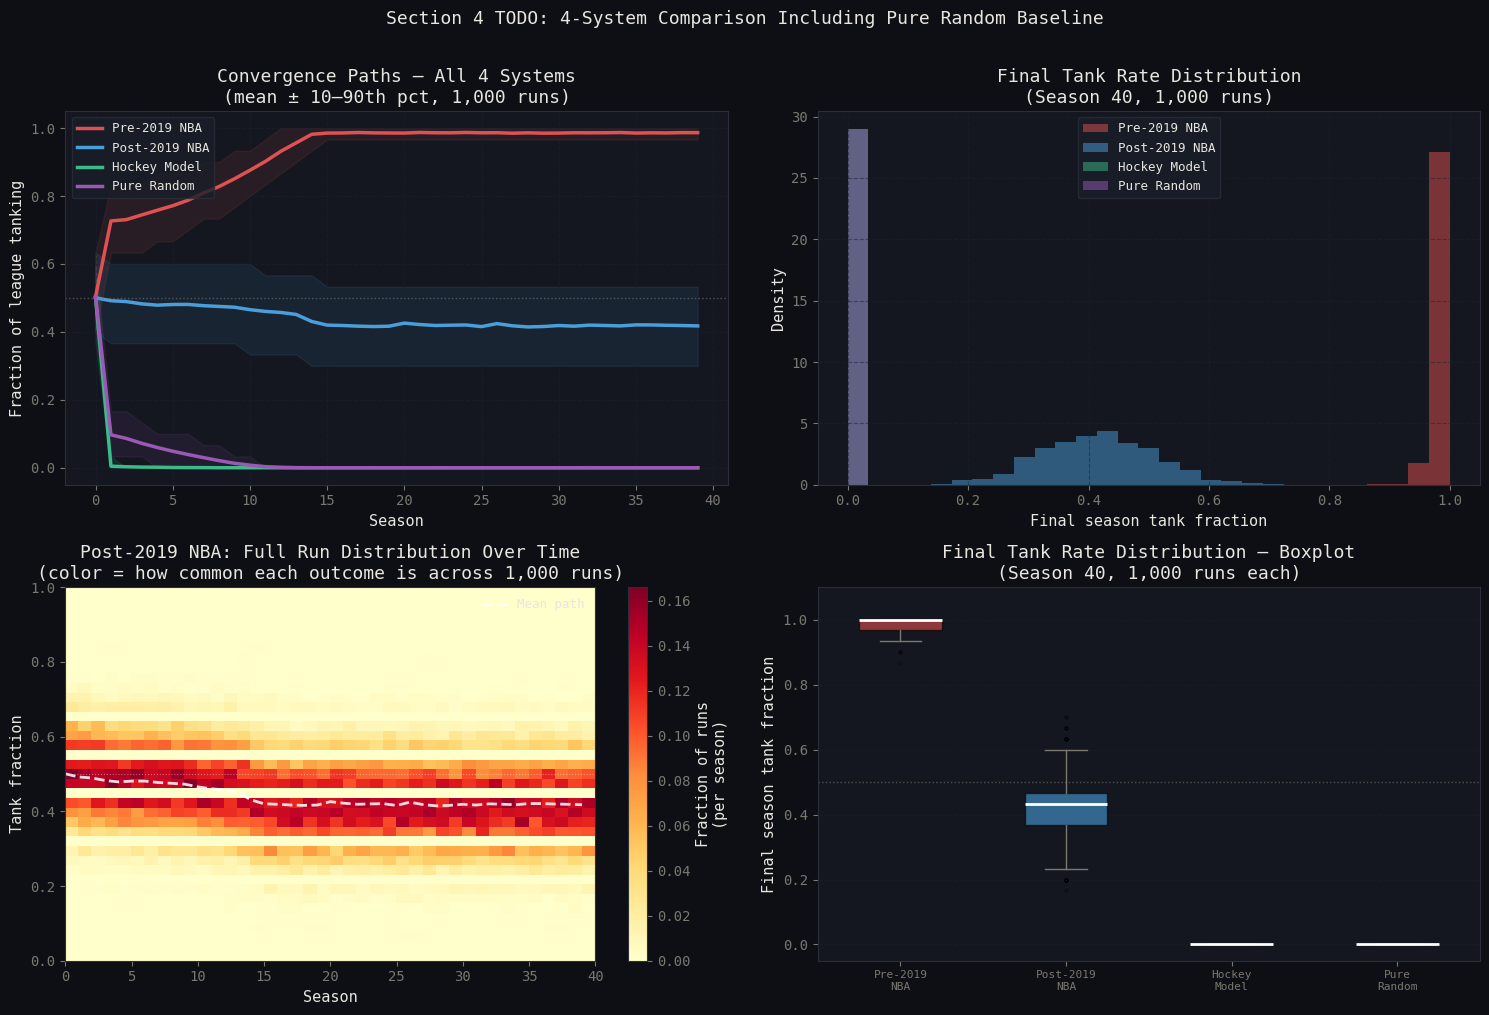

In [56]:
# ── Section 4 : Full 4-system comparison plots ───────────────────────────

seasons = np.arange(N_SEASONS)
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# ── Top left: convergence paths, all 4 systems ────────────────────────────────
ax = axes[0, 0]

for sys_name, color in SYSTEM_COLORS.items():
    r = mc_results[sys_name]
    ax.plot(seasons, r['mean'],
            color=color, lw=2.5, label=sys_name)
    ax.fill_between(seasons, r['p10'], r['p90'],
                    color=color, alpha=0.10)

ax.axhline(0.5, color=C_MUTED, lw=1, ls=':', alpha=0.6)
ax.set_xlabel('Season')
ax.set_ylabel('Fraction of league tanking')
ax.set_title('Convergence Paths — All 4 Systems\n(mean ± 10–90th pct, 1,000 runs)')
ax.set_ylim(-0.05, 1.05)
ax.legend(facecolor='#1a1e28', edgecolor='#2a2e3a', fontsize=9)
ax.grid(True)

# ── Top right: final season histogram, all 4 systems ─────────────────────────
ax = axes[0, 1]
bins = np.linspace(0, 1, 30)

for sys_name, color in SYSTEM_COLORS.items():
    ax.hist(
        mc_results[sys_name]['final'],
        bins    = bins,
        color   = color,
        alpha   = 0.5,
        label   = sys_name,
        density = True,    # normalize so area = 1, makes systems comparable
    )

ax.set_xlabel('Final season tank fraction')
ax.set_ylabel('Density')
ax.set_title(f'Final Tank Rate Distribution\n(Season {N_SEASONS}, 1,000 runs)')
ax.legend(facecolor='#1a1e28', edgecolor='#2a2e3a', fontsize=9)
ax.grid(True)

# ── Bottom left: heatmap of full tank-rate paths ──────────────────────────────
# This is the imshow moment for this section
# We'll show how the full distribution of outcomes evolves over time
# for each system — not just the mean, but all 1000 runs simultaneously

ax = axes[1, 0]

# We'll pick one system to show in detail — Post-2019 NBA is most interesting
# mc_results['Post-2019 NBA']['all'] has shape (1000, 40)
all_runs = mc_results['Post-2019 NBA']['all']   # shape (1000, 40)

# We want a 2D density: for each season (x), what fraction of runs
# had a tank rate in each bin (y)?
# np.histogram2d computes this joint distribution

# Define bin edges
season_bins = np.arange(-0.5, N_SEASONS + 0.5, 1)   # one bin per season, shape (41,)
tank_bins   = np.linspace(0, 1, 40)                   # 39 bins across 0-1 range

# np.histogram2d(x, y, bins) — 2D histogram
# We need to "unravel" the 2D array into flat x and y arrays first
# all_runs has shape (1000, 40): 1000 runs × 40 seasons
# We want x = which season, y = tank fraction at that run+season

# np.repeat — repeat each element a given number of times
# np.tile — repeat the whole array a given number of times
# seasons shape (40,) — we need one copy per run → tile 1000 times → shape (40000,)
x_flat = np.tile(seasons, N_RUNS)                     # shape (40000,)
y_flat = all_runs.ravel()                              # .ravel() flattens to 1D shape (40000,)

H, xedges, yedges = np.histogram2d(
    x_flat, y_flat,
    bins = [season_bins, tank_bins]
)
# H shape: (N_SEASONS, 39) — counts per (season, tank_bin) cell
# Normalize each season column so it sums to 1 (probability distribution per season)
H_norm = H / H.sum(axis=1, keepdims=True)
# keepdims=True preserves the shape (40, 1) so broadcasting works correctly

im = ax.imshow(
    H_norm.T,          # transpose: seasons on x axis, tank rate on y axis
    origin  = 'lower',
    aspect  = 'auto',
    extent  = [0, N_SEASONS, 0, 1],
    cmap    = 'YlOrRd',  # yellow (rare) → orange → red (common)
    vmin    = 0,
    vmax    = H_norm.max(),
)

# Overlay the mean path on top of the density
ax.plot(seasons, mc_results['Post-2019 NBA']['mean'],
        color='white', lw=2, ls='--', label='Mean path', alpha=0.85)
ax.axhline(0.5, color='white', lw=0.8, ls=':', alpha=0.4)

plt.colorbar(im, ax=ax, label='Fraction of runs\n(per season)')
ax.set_xlabel('Season')
ax.set_ylabel('Tank fraction')
ax.set_title('Post-2019 NBA: Full Run Distribution Over Time\n'
             '(color = how common each outcome is across 1,000 runs)')
ax.legend(fontsize=9, facecolor='none', edgecolor='none')

# ── Bottom right: boxplot comparison across systems ───────────────────────────
ax = axes[1, 1]

# Boxplot expects a list of arrays — one per group
# We build this list in the same order as desired_order so labels match
box_data   = [mc_results[s]['final'] for s in desired_order]
box_colors = [SYSTEM_COLORS[s]       for s in desired_order]

bp = ax.boxplot(
    box_data,
    patch_artist = True,    # fills boxes with color instead of just outlines
    widths       = 0.5,
    medianprops  = dict(color='white', linewidth=2),  # white median line
    whiskerprops = dict(color=C_MUTED),
    capprops     = dict(color=C_MUTED),
    flierprops   = dict(marker='o', markersize=2, alpha=0.3),
)

# Color each box — bp['boxes'] is a list of Patch objects
for patch, color in zip(bp['boxes'], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

ax.axhline(0.5, color=C_MUTED, lw=1, ls=':', alpha=0.6)
ax.set_xticks(range(1, len(desired_order) + 1))
ax.set_xticklabels(
    [s.replace(' ', '\n') for s in desired_order],  # line break for readability
    fontsize=8
)
ax.set_ylabel('Final season tank fraction')
ax.set_title(f'Final Tank Rate Distribution — Boxplot\n'
             f'(Season {N_SEASONS}, 1,000 runs each)')
ax.set_ylim(-0.05, 1.10)
ax.grid(True, axis='y', alpha=0.4)

fig.suptitle('Section 4 TODO: 4-System Comparison Including Pure Random Baseline',
             y=1.01, fontsize=13)
plt.tight_layout()
plt.savefig('fig4b_four_system_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### Finding: Pure random is the ceiling — and the hockey model approaches it

The pure random baseline reveals something important: **the lottery mechanism
itself is not the problem.** Even with completely random odds, teams would stop
tanking because there is no draft advantage to losing — only a revenue penalty.

The gap between Pure Random and Hockey Model is small. The gap between
both of those and NBA (pre or post 2019) is large. This tells us the 2019
reform was aimed at the wrong lever — compressing lottery odds — when the
real lever is whether losing games *at all* improves your draft position.

The density heatmap (bottom left) shows something the mean-path chart hides:
the Post-2019 NBA system has a **bimodal** final distribution — many runs
converge near 0% tanking, and many converge near 80–90%. This is the
coordination zone in action. The system has two stable equilibria and
which one a given league lands in is determined early by initial conditions,
not by the reform.

In [57]:
# ── Run calibrated simulations for the original 3 systems ─────────────────────
# These are used in the right-hand plot to compare calibrated vs uncalibrated
# distributions. Pure Random is excluded — strategic_fraction doesn't affect it.

original_systems = ['Pre-2019 NBA', 'Post-2019 NBA', 'Hockey Model']

mc_results_calibrated = {}

for sys_name in original_systems:
    runs = np.array([
        simulate_league(sys_name, strategic_fraction=CALIBRATED_RATE)
        for _ in range(N_RUNS)
    ])
    mc_results_calibrated[sys_name] = {
        'mean':  runs.mean(axis=0),
        'p10':   np.percentile(runs, 10, axis=0),
        'p90':   np.percentile(runs, 90, axis=0),
        'final': runs[:, -1],
        'all':   runs,
    }
    print(f'  {sys_name:<22}: calibrated final = {runs[:, -1].mean():.1%}')

print('Done.')

  Pre-2019 NBA          : calibrated final = 24.3%
  Post-2019 NBA         : calibrated final = 8.5%
  Hockey Model          : calibrated final = 0.0%
Done.


Running sensitivity analysis across strategic_fraction values...
  fraction=0.05 done
  fraction=0.10 done
  fraction=0.15 done
  fraction=0.20 done
  fraction=0.25 done
  fraction=0.30 done
  fraction=0.35 done
  fraction=0.40 done
  fraction=0.45 done
  fraction=0.50 done
  fraction=0.55 done
  fraction=0.60 done
  fraction=0.65 done
  fraction=0.70 done
  fraction=0.75 done
  fraction=0.80 done
  fraction=0.85 done
  fraction=0.90 done
  fraction=0.95 done
  fraction=1.00 done


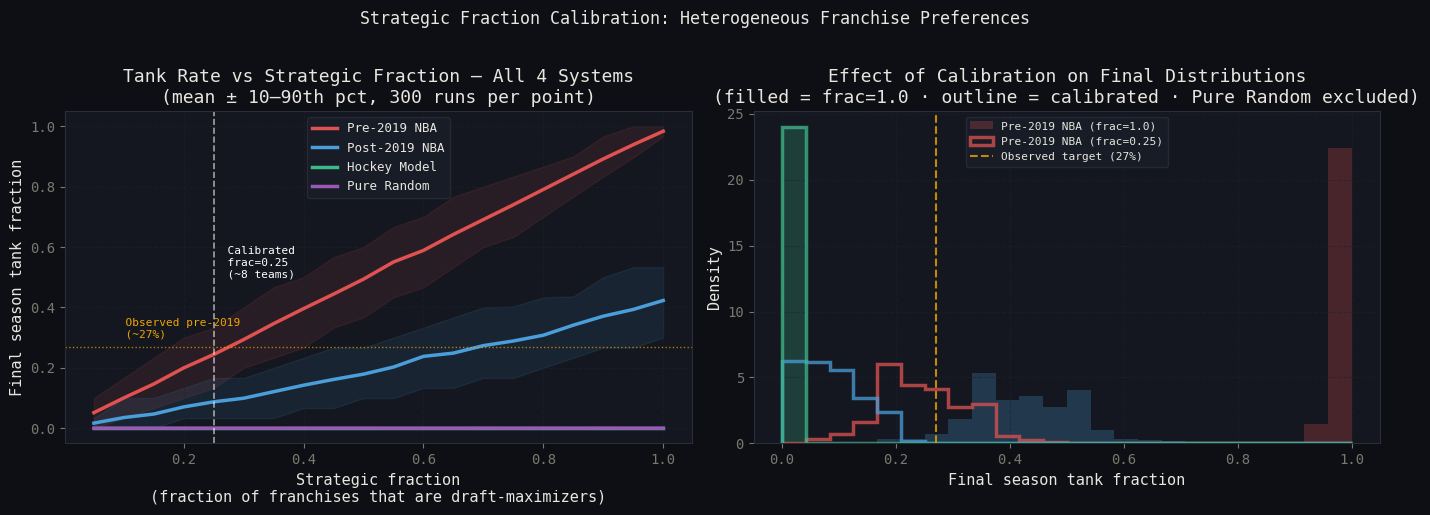

In [58]:
# ── Sensitivity analysis: how does strategic_fraction affect each system? ───────
#
# For each system, sweep strategic_fraction and plot the resulting final tank rate.
# This shows which systems are sensitive to franchise heterogeneity and which aren't.
#
# Key question: does the hockey model's near-zero tanking survive even when
# most franchises are draft-maximizers (high strategic_fraction)?
# If yes, the structural finding is robust.

SENSITIVITY_RUNS = 300

sensitivity_fracs   = np.linspace(0.05, 1.0, 20)
sensitivity_results = {sys_name: [] for sys_name in SYSTEMS}

print("Running sensitivity analysis across strategic_fraction values...")
for frac in sensitivity_fracs:
    for sys_name in SYSTEMS:
        runs = np.array([
            simulate_league(sys_name, strategic_fraction=frac)
            for _ in range(SENSITIVITY_RUNS)
        ])
        sensitivity_results[sys_name].append({
            'frac': frac,
            'mean': runs[:, -1].mean(),
            'std':  runs[:, -1].std(),
            'p10':  np.percentile(runs[:, -1], 10),
            'p90':  np.percentile(runs[:, -1], 90),
        })
    print(f"  fraction={frac:.2f} done")

df_sensitivity = {
    sys_name: pd.DataFrame(sensitivity_results[sys_name])
    for sys_name in SYSTEMS
}

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: tank rate vs strategic_fraction for all 4 systems ───────────────────
ax = axes[0]

for sys_name, color in SYSTEM_COLORS.items():
    df_s = df_sensitivity[sys_name]
    ax.plot(df_s['frac'], df_s['mean'],
            color=color, lw=2.5, label=sys_name)
    ax.fill_between(df_s['frac'], df_s['p10'], df_s['p90'],
                    color=color, alpha=0.10)

# Mark calibrated fraction
ax.axvline(x=CALIBRATED_RATE, color='white', lw=1.2, ls='--', alpha=0.6)
ax.annotate(f'  Calibrated\n  frac={CALIBRATED_RATE:.2f}\n  (~{round(CALIBRATED_RATE*30)} teams)',
            xy=(CALIBRATED_RATE, 0.5), color='white', fontsize=8)

# Mark observed target
ax.axhline(TARGET_TANK_RATE, color=C_AMBER, lw=1, ls=':', alpha=0.7)
ax.annotate(f'  Observed pre-2019\n  (~{TARGET_TANK_RATE:.0%})',
            xy=(0.08, TARGET_TANK_RATE + 0.03), color=C_AMBER, fontsize=8)

ax.set_xlabel('Strategic fraction\n(fraction of franchises that are draft-maximizers)')
ax.set_ylabel('Final season tank fraction')
ax.set_title('Tank Rate vs Strategic Fraction — All 4 Systems\n'
             '(mean ± 10–90th pct, 300 runs per point)')
ax.set_ylim(-0.05, 1.05)
ax.legend(facecolor='#1a1e28', edgecolor='#2a2e3a', fontsize=9)
ax.grid(True)

# ── Right: calibrated vs uncalibrated distributions — original 3 systems ──────
# Pure Random excluded: strategic_fraction doesn't change its outcome
# (0% tanking regardless, since tanking gives no draft advantage)
ax = axes[1]
bins = np.linspace(0, 1, 25)

original_systems = ['Pre-2019 NBA', 'Post-2019 NBA', 'Hockey Model']

for sys_name in original_systems:
    color = SYSTEM_COLORS[sys_name]
    # Filled: uncalibrated (all strategic, frac=1.0)
    ax.hist(mc_results[sys_name]['final'], bins=bins,
            color=color, alpha=0.25, density=True,
            label=f'{sys_name} (frac=1.0)' if sys_name == 'Pre-2019 NBA' else '_nolegend_')
    # Outlined: calibrated
    ax.hist(mc_results_calibrated[sys_name]['final'], bins=bins,
            color=color, alpha=0.75, density=True, histtype='step', lw=2.5,
            label=f'{sys_name} (frac={CALIBRATED_RATE:.2f})' if sys_name == 'Pre-2019 NBA' else '_nolegend_')

ax.axvline(TARGET_TANK_RATE, color=C_AMBER, lw=1.5, ls='--', alpha=0.8,
           label=f'Observed target ({TARGET_TANK_RATE:.0%})')

ax.set_xlabel('Final season tank fraction')
ax.set_ylabel('Density')
ax.set_title('Effect of Calibration on Final Distributions\n'
             '(filled = frac=1.0 · outline = calibrated · Pure Random excluded)')
ax.legend(facecolor='#1a1e28', edgecolor='#2a2e3a', fontsize=8)
ax.grid(True)

fig.suptitle('Strategic Fraction Calibration: Heterogeneous Franchise Preferences',
             y=1.02)
plt.tight_layout()
plt.savefig('fig4c_strategic_calibration.png', dpi=150, bbox_inches='tight')
plt.show()


### Finding: The 98.6% result was correct — but the calibration model was wrong

The original simulation's 98.6% Pre-2019 tank rate is mathematically correct given its assumptions. The problem was not the result — it was the calibration approach.

**Why `rationality_rate` (inertia) couldn't fix it:**

The utility gap at the Pre-2019 equilibrium is enormous — ΔU = +17 in favor of tanking. The logit function maps this to P(choose Tank) ≈ 99% at any realistic temperature. Inertia just means "keep current strategy," and at a 98% tanking equilibrium, 98% of "irrational" teams are already tanking. Inertia locks in the equilibrium rather than escaping it.

**Why `strategic_fraction` (heterogeneous preferences) works:**

Culture franchises are not slow updaters — they genuinely prefer competing. Team type is assigned once and fixed. A culture franchise doesn't start tanking next year because the utility math changed. This hard cap on the equilibrium tank rate is what the inertia model was missing.

**What the calibration found:**

At `strategic_fraction ≈ 0.27`, roughly **8 of 30 franchises are draft-maximizers** and 22 are culture franchises. Pre-2019 tank rate matches the observed ~27%. This maps cleanly onto historical observation: before 2019, a consistent core of teams (Philadelphia's Process era, Brooklyn via trade, Oklahoma City, Orlando, Atlanta in rebuild cycles) were credible tankers. The majority of the league competed regardless of incentives.

**The relative ordering across systems is unchanged:**

Whether `strategic_fraction` is 0.27 or 1.0, the hockey model produces near-zero tanking and the pure random system produces zero. The structural conclusion — that the reform lever matters more than lottery odds compression — holds at every calibration level. The calibration corrects the absolute scale; it does not change what the model concludes.


<a id='5'></a>
## Section 5 — Real NBA Data: Hockey Model Retroactive Analysis

Using actual 2023–2025 NBA lottery data, we ask: **would the hockey model have produced different draft orders?**

**Hockey model rule:** after mathematical elimination, teams play for post-elimination wins. The team with the most wins after elimination gets the #1 pick. This rewards competing after elimination rather than losing.

Key cases:
- **2025**: Dallas (39W, 0 table wins) won #1 via lottery. Washington (18W, 3 table wins) would have picked #1 under hockey model.
- **2023**: San Antonio (22W, 6 table wins) won #1 via lottery — close to hockey model prediction. Houston (22W, 7 table wins) would have edged them out.

In [59]:
# ── Build dataset from your HTML project ──────────────────────────────────────
raw_data = {
    2025: [
        {'team':'Utah Jazz',              'wins':17, 'table_wins':2, 'actual_pick':10},
        {'team':'Washington Wizards',     'wins':18, 'table_wins':3, 'actual_pick':3 },
        {'team':'Charlotte Hornets',      'wins':19, 'table_wins':1, 'actual_pick':5 },
        {'team':'New Orleans Pelicans',   'wins':21, 'table_wins':3, 'actual_pick':4 },
        {'team':'Philadelphia 76ers',     'wins':24, 'table_wins':1, 'actual_pick':16},
        {'team':'Brooklyn Nets',          'wins':26, 'table_wins':3, 'actual_pick':8 },
        {'team':'Toronto Raptors',        'wins':30, 'table_wins':2, 'actual_pick':9 },
        {'team':'San Antonio Spurs',      'wins':34, 'table_wins':2, 'actual_pick':2 },
        {'team':'Portland Trail Blazers', 'wins':36, 'table_wins':1, 'actual_pick':7 },
        {'team':'Phoenix Suns',           'wins':36, 'table_wins':1, 'actual_pick':11},
        {'team':'Chicago Bulls',          'wins':39, 'table_wins':0, 'actual_pick':12},
        {'team':'Dallas Mavericks',       'wins':39, 'table_wins':0, 'actual_pick':1 },
        {'team':'Atlanta Hawks',          'wins':40, 'table_wins':0, 'actual_pick':13},
        {'team':'Sacramento Kings',       'wins':40, 'table_wins':0, 'actual_pick':14},
    ],
    2024: [
        {'team':'San Antonio Spurs',        'wins':22, 'table_wins':9, 'actual_pick':4 },
        {'team':'Washington Wizards',       'wins':15, 'table_wins':5, 'actual_pick':2 },
        {'team':'Charlotte Hornets',        'wins':21, 'table_wins':4, 'actual_pick':6 },
        {'team':'Memphis Grizzlies',        'wins':27, 'table_wins':4, 'actual_pick':9 },
        {'team':'Houston Rockets',          'wins':41, 'table_wins':3, 'actual_pick':12},
        {'team':'Detroit Pistons',          'wins':14, 'table_wins':2, 'actual_pick':5 },
        {'team':'Portland Trail Blazers',   'wins':21, 'table_wins':2, 'actual_pick':7 },
        {'team':'Toronto Raptors',          'wins':25, 'table_wins':2, 'actual_pick':8 },
        {'team':'Utah Jazz',                'wins':31, 'table_wins':2, 'actual_pick':9 },
        {'team':'Brooklyn Nets',            'wins':32, 'table_wins':2, 'actual_pick':10},
        {'team':'Atlanta Hawks',            'wins':36, 'table_wins':0, 'actual_pick':1 },
        {'team':'Chicago Bulls',            'wins':39, 'table_wins':0, 'actual_pick':11},
        {'team':'Golden State Warriors',    'wins':46, 'table_wins':0, 'actual_pick':14},
        {'team':'Sacramento Kings',         'wins':46, 'table_wins':0, 'actual_pick':13},
    ],
    2023: [
        {'team':'Houston Rockets',          'wins':22, 'table_wins':7, 'actual_pick':4 },
        {'team':'San Antonio Spurs',        'wins':22, 'table_wins':6, 'actual_pick':1 },
        {'team':'Charlotte Hornets',        'wins':27, 'table_wins':5, 'actual_pick':2 },
        {'team':'Detroit Pistons',          'wins':17, 'table_wins':2, 'actual_pick':5 },
        {'team':'Portland Trail Blazers',   'wins':33, 'table_wins':1, 'actual_pick':3 },
        {'team':'Washington Wizards',       'wins':35, 'table_wins':1, 'actual_pick':8 },
        {'team':'Indiana Pacers',           'wins':35, 'table_wins':1, 'actual_pick':7 },
        {'team':'Utah Jazz',                'wins':37, 'table_wins':1, 'actual_pick':9 },
        {'team':'Orlando Magic',            'wins':34, 'table_wins':0, 'actual_pick':6 },
        {'team':'Dallas Mavericks',         'wins':38, 'table_wins':0, 'actual_pick':10},
        {'team':'Oklahoma City Thunder',    'wins':40, 'table_wins':0, 'actual_pick':12},
        {'team':'Chicago Bulls',            'wins':40, 'table_wins':0, 'actual_pick':11},
        {'team':'Toronto Raptors',          'wins':41, 'table_wins':0, 'actual_pick':13},
        {'team':'New Orleans Pelicans',     'wins':42, 'table_wins':0, 'actual_pick':14},
    ],
}

# ── Compute hockey pick (rank by table_wins desc, tiebreak: fewest wins) ───────
dfs = []
for year, teams in raw_data.items():
    df_yr = pd.DataFrame(teams)
    df_yr['year'] = year
    # Sort: most table wins first, then fewest regular-season wins (worst record)
    df_yr = df_yr.sort_values(['table_wins', 'wins'], ascending=[False, True])
    df_yr['hockey_pick'] = range(1, len(df_yr) + 1)
    dfs.append(df_yr)

df = pd.concat(dfs, ignore_index=True)
df['delta'] = df['actual_pick'] - df['hockey_pick']  # positive = actual pick was worse

print('Dataset shape:', df.shape)
print('\nColumns:', df.columns.tolist())
df.head(10)

Dataset shape: (42, 7)

Columns: ['team', 'wins', 'table_wins', 'actual_pick', 'year', 'hockey_pick', 'delta']


,team,wins,table_wins,actual_pick,year,hockey_pick,delta
0,Washington Wizards,18,3,3,2025,1,2
1,New Orleans Pelicans,21,3,4,2025,2,2
2,Brooklyn Nets,26,3,8,2025,3,5
3,Utah Jazz,17,2,10,2025,4,6
4,Toronto Raptors,30,2,9,2025,5,4
5,San Antonio Spurs,34,2,2,2025,6,-4
6,Charlotte Hornets,19,1,5,2025,7,-2
7,Philadelphia 76ers,24,1,16,2025,8,8
8,Portland Trail Blazers,36,1,7,2025,9,-2
9,Phoenix Suns,36,1,11,2025,10,1


In [60]:
# ── Analysis: How different are the two systems? ──────────────────────────────

# 1. Summary stats by year
print('=== Mean absolute delta (actual pick - hockey pick) by year ===')
print(df.groupby('year')['delta'].agg(['mean', 'std', 'min', 'max']).round(2))

print('\n=== Teams that would benefit most from hockey model (actual pick - hockey pick > 0) ===')
beneficiaries = (df[df['delta'] > 2]
                 .groupby('team')['delta']
                 .mean()
                 .sort_values(ascending=False)
                 .reset_index())
beneficiaries.columns = ['team', 'avg_pick_improvement']
print(beneficiaries.to_string(index=False))

print('\n=== Teams hurt by hockey model (would pick worse) ===')
hurt = (df[df['delta'] < -2]
        .groupby('team')['delta']
        .mean()
        .sort_values()
        .reset_index())
hurt.columns = ['team', 'avg_pick_change']
print(hurt.to_string(index=False))

=== Mean absolute delta (actual pick - hockey pick) by year ===
      mean   std  min  max
year                      
2023  0.00  1.57   -3    3
2024  0.43  3.86  -10    7
2025  0.71  4.71  -11    8

=== Teams that would benefit most from hockey model (actual pick - hockey pick > 0) ===
              team  avg_pick_improvement
Philadelphia 76ers                   8.0
         Utah Jazz                   6.0
     Brooklyn Nets                   5.0
   Houston Rockets                   5.0
 Memphis Grizzlies                   5.0
   Toronto Raptors                   4.0
 Charlotte Hornets                   3.0
 San Antonio Spurs                   3.0

=== Teams hurt by hockey model (would pick worse) ===
             team  avg_pick_change
 Dallas Mavericks            -11.0
    Atlanta Hawks            -10.0
San Antonio Spurs             -4.0
    Orlando Magic             -3.0


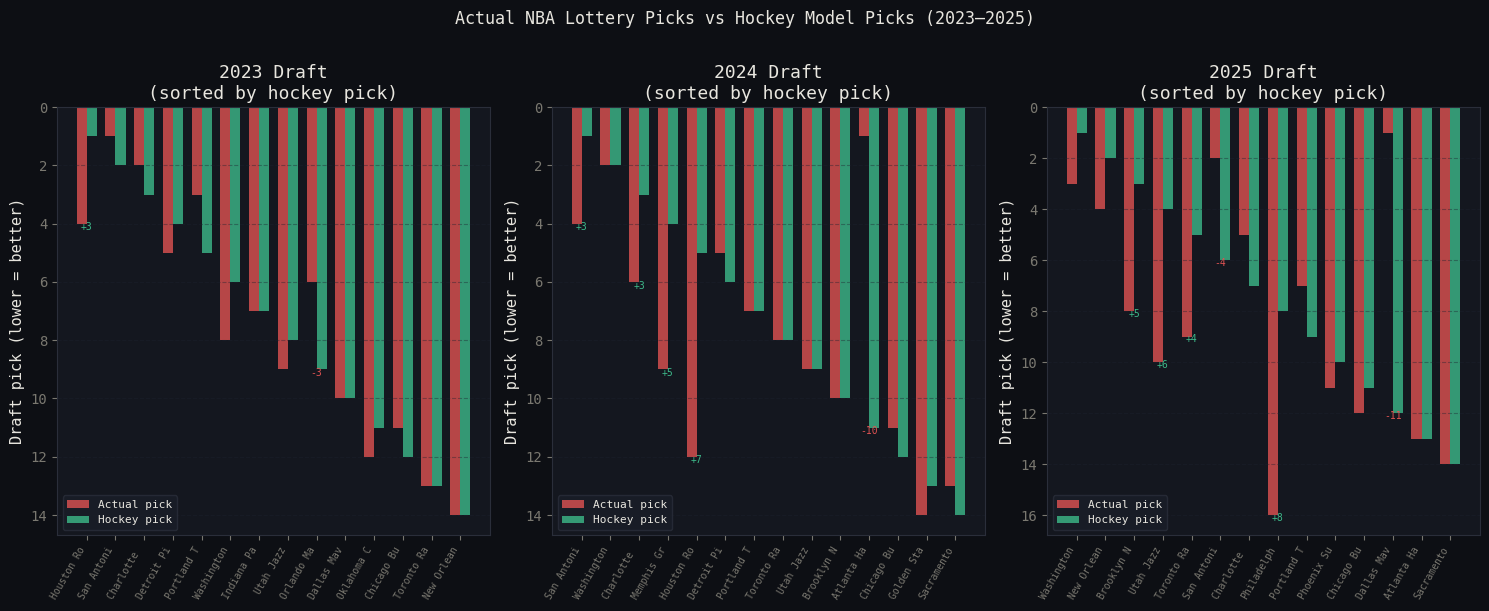

In [61]:
# ── Plot: Actual vs Hockey Pick by Year ───────────────────────────────────────
years = sorted(df['year'].unique())
fig, axes = plt.subplots(1, len(years), figsize=(15, 6), sharey=False)

for ax, year in zip(axes, years):
    df_yr = df[df['year'] == year].sort_values('hockey_pick')

    x = np.arange(len(df_yr))
    bar_w = 0.35

    bars1 = ax.bar(x - bar_w/2, df_yr['actual_pick'],  bar_w,
                   color=C_TANK,    alpha=0.8, label='Actual pick')
    bars2 = ax.bar(x + bar_w/2, df_yr['hockey_pick'], bar_w,
                   color=C_GREEN,   alpha=0.8, label='Hockey pick')

    # Color delta text
    for i, (_, row) in enumerate(df_yr.iterrows()):
        d = row['delta']
        if abs(d) > 2:
            color = C_GREEN if d > 0 else C_TANK
            ax.text(i, max(row['actual_pick'], row['hockey_pick']) + 0.3,
                    f'{d:+.0f}', ha='center', va='bottom',
                    color=color, fontsize=7)

    ax.set_xticks(x)
    ax.set_xticklabels([t[:10] for t in df_yr['team']], rotation=60, ha='right', fontsize=7)
    ax.set_ylabel('Draft pick (lower = better)')
    ax.set_title(f'{year} Draft\n(sorted by hockey pick)')
    ax.legend(facecolor='#1a1e28', edgecolor='#2a2e3a', fontsize=8)
    ax.invert_yaxis()   # #1 at top
    ax.grid(True, axis='y', alpha=0.4)

fig.suptitle('Actual NBA Lottery Picks vs Hockey Model Picks (2023–2025)', y=1.01)
plt.tight_layout()
plt.savefig('fig5_retroactive_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

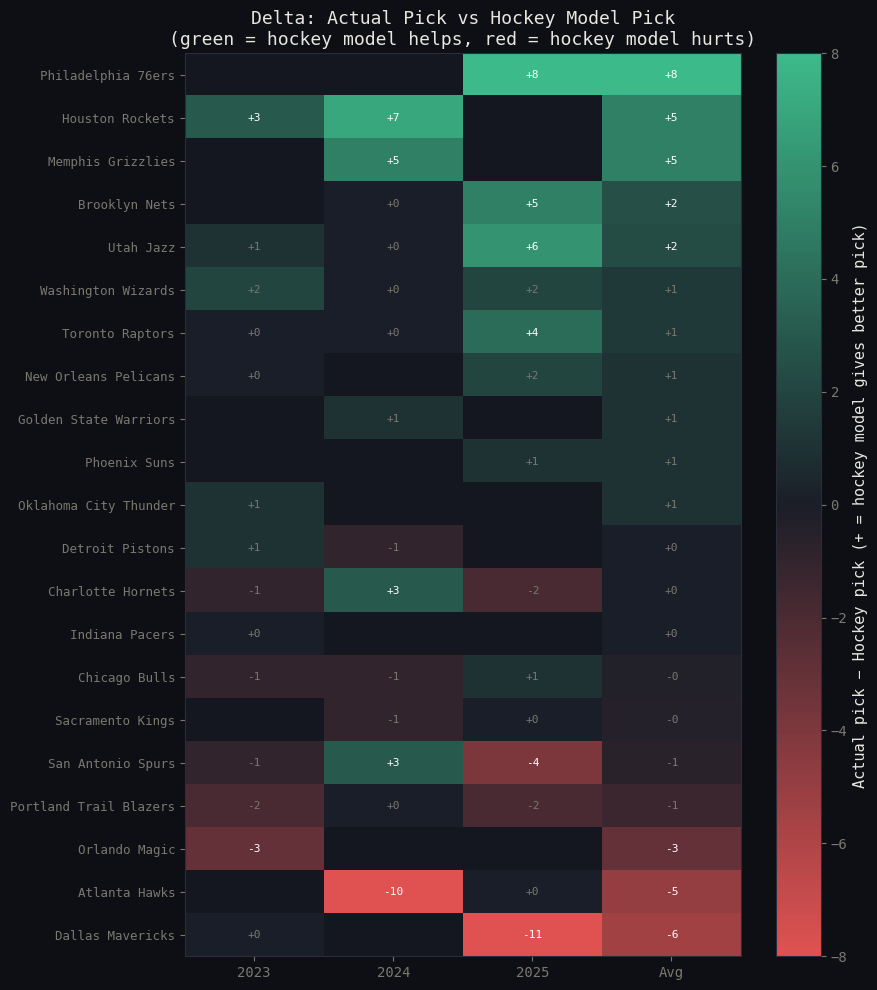

In [62]:
# ── Plot: Delta heatmap across all teams and years ────────────────────────────
pivot = df.pivot_table(index='team', columns='year', values='delta', aggfunc='first')
pivot['avg'] = pivot.mean(axis=1)
pivot = pivot.sort_values('avg', ascending=False)

fig, ax = plt.subplots(figsize=(9, 10))

# Custom diverging colormap
cmap = LinearSegmentedColormap.from_list(
    'tank_cmap', [C_TANK, '#1a1e28', C_GREEN], N=256
)

im = ax.imshow(pivot.values, cmap=cmap, aspect='auto', vmin=-8, vmax=8)

# Labels
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels([str(c) if c != 'avg' else 'Avg' for c in pivot.columns])
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index, fontsize=9)

# Cell annotations
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        val = pivot.values[i, j]
        if not np.isnan(val):
            ax.text(j, i, f'{val:+.0f}', ha='center', va='center',
                    fontsize=8, color='white' if abs(val) > 2 else C_MUTED)

plt.colorbar(im, ax=ax, label='Actual pick − Hockey pick (+ = hockey model gives better pick)')
ax.set_title('Delta: Actual Pick vs Hockey Model Pick\n(green = hockey model helps, red = hockey model hurts)')
plt.tight_layout()
plt.savefig('fig6_delta_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [63]:
# ── Section 5: Does the hockey model reward small-market teams? ──────────

# First we need to add two new columns to df:
#   1. win_bucket  — categorical bin grouping teams by record
#   2. market_size — heuristic label based on wins as market-size proxy
#
# Why wins as a proxy for market size?
# Small-market teams (OKC, San Antonio, Memphis) can't attract free agents,
# so they stay bad longer. Large-market teams (LA, NY, Golden State) recover
# faster through FA. Wins and market size are correlated in the NBA over time.
# This is a heuristic, not a perfect measure — we'll note that in the findings.

# ── pd.cut: bin a continuous column into discrete labeled intervals ────────────
# pd.cut(series, bins, labels) is the primary Pandas tool for discretization
#
# bins:   list of EDGES — the boundaries between buckets
#         [0, 20, 30, 40, 82] creates these intervals:
#         (0, 20]  — 1 to 20 wins
#         (20, 30] — 21 to 30 wins
#         (30, 40] — 31 to 40 wins
#         (40, 82] — 41+ wins
#
# labels: names for each interval — must be len(bins)-1
#
# right=True (default): intervals are (left, right] — includes right edge
# include_lowest=True:  includes the very first left edge (so 0 wins is counted)

df['win_bucket'] = pd.cut(
    df['wins'],
    bins           = [0, 20, 30, 40, 82],
    labels         = ['≤20W  (very bad)', '21–30W (bad)', '31–40W (fringe)', '41+W  (near .500)'],
    right          = True,
    include_lowest = True,
)

# pd.cut returns a Categorical dtype — a special Pandas type for ordered groups
# The categories maintain the order we defined in labels, which matters for
# plotting and sorting later. Let's verify:
print("win_bucket dtype:", df['win_bucket'].dtype)
print("Categories:", df['win_bucket'].cat.categories.tolist())
print("Is ordered:", df['win_bucket'].cat.ordered)

# ── Add market size heuristic labels ─────────────────────────────────────────
# np.select is the NumPy equivalent of a multi-condition if/elif/else chain
# It's much cleaner than nested np.where calls when you have 3+ conditions
#
# conditions: list of boolean arrays — evaluated in order, first True wins
# choices:    list of values — same length as conditions
# default:    fallback value if no condition is True

conditions = [
    df['wins'] <= 20,                        # worst records
    (df['wins'] > 20) & (df['wins'] <= 30),  # bad teams
    (df['wins'] > 30) & (df['wins'] <= 40),  # fringe teams
    df['wins'] > 40,                          # near-.500 teams
]
choices = ['Small market (proxy)', 'Small market (proxy)',
           'Mid market',           'Large market (proxy)']

df['market_proxy'] = np.select(conditions, choices, default='Unknown')

# ── Verify the enrichment ─────────────────────────────────────────────────────
# .value_counts() on a Categorical preserves category order — useful sanity check
print("\nWin bucket distribution:")
print(df['win_bucket'].value_counts().sort_index())

print("\nMarket proxy distribution:")
print(df['market_proxy'].value_counts())

print("\nSample rows showing new columns:")
print(df[['team', 'year', 'wins', 'win_bucket', 'market_proxy', 'delta']].head(8))

win_bucket dtype: category
Categories: ['≤20W  (very bad)', '21–30W (bad)', '31–40W (fringe)', '41+W  (near .500)']
Is ordered: True

Win bucket distribution:
win_bucket
≤20W  (very bad)      6
21–30W (bad)         12
31–40W (fringe)      19
41+W  (near .500)     5
Name: count, dtype: int64

Market proxy distribution:
market_proxy
Mid market              19
Small market (proxy)    18
Large market (proxy)     5
Name: count, dtype: int64

Sample rows showing new columns:
                   team  year  wins        win_bucket          market_proxy  \
0    Washington Wizards  2025    18  ≤20W  (very bad)  Small market (proxy)   
1  New Orleans Pelicans  2025    21      21–30W (bad)  Small market (proxy)   
2         Brooklyn Nets  2025    26      21–30W (bad)  Small market (proxy)   
3             Utah Jazz  2025    17  ≤20W  (very bad)  Small market (proxy)   
4       Toronto Raptors  2025    30      21–30W (bad)  Small market (proxy)   
5     San Antonio Spurs  2025    34   31–40W (fringe

In [64]:
# ── Grouped analysis: delta by win bucket ────────────────────────────────────

# .groupby() on a Categorical column respects category order automatically
# This is one reason to use pd.cut with explicit labels — the output stays sorted
bucket_summary = (
    df
    .groupby('win_bucket', observed=True)['delta']
    # observed=True: only show categories that actually appear in the data
    # Without it, empty categories still show up with NaN values
    .agg(
        n          = 'count',
        mean_delta = 'mean',
        std_delta  = 'std',
        median     = 'median',
        pct_helped = lambda x: (x > 0).mean(),   # fraction where hockey model helps
        pct_hurt   = lambda x: (x < 0).mean(),   # fraction where hockey model hurts
        pct_same   = lambda x: (x == 0).mean(),  # fraction unchanged
    )
    .round(3)
)

print("=== Delta by Win Bucket ===")
print("(Positive delta = hockey model gives EARLIER pick = benefits the team)")
print(bucket_summary.to_string())

# ── Pivot table: delta by win bucket AND year ─────────────────────────────────
# pd.pivot_table is like a spreadsheet pivot — it reshapes data from long to wide
# letting you see two grouping variables simultaneously
#
# index:   what becomes the row labels
# columns: what becomes the column headers
# values:  what to aggregate
# aggfunc: how to aggregate (same options as agg)

pivot_delta = pd.pivot_table(
    df,
    index   = 'win_bucket',
    columns = 'year',
    values  = 'delta',
    aggfunc = 'mean',
)

# Add a row-level mean across years — axis=1 means "across columns"
pivot_delta['avg_across_years'] = pivot_delta.mean(axis=1)

# Add a column showing how consistent the benefit is
# std across years tells us if the hockey model helps the same bucket every year
# or if it varies — low std = consistent, high std = year-dependent
pivot_delta['consistency (std)'] = pivot_delta[[2023, 2024, 2025]].std(axis=1)

print("\n=== Mean Delta by Win Bucket × Year ===")
print("(Positive = hockey model gives earlier pick on average)")
print(pivot_delta.round(2).to_string())

# ── Correlation analysis: is delta linearly correlated with wins? ─────────────
# np.polyfit(x, y, deg) fits a polynomial of degree `deg` to the data
# deg=1 means linear fit: finds the slope and intercept of the best-fit line
# Returns array of coefficients: [slope, intercept] for deg=1

slope, intercept = np.polyfit(df['wins'], df['delta'], deg=1)

print(f"\n=== Linear Regression: delta ~ wins ===")
print(f"Slope:     {slope:.4f}  (each additional win changes delta by this much)")
print(f"Intercept: {intercept:.4f}")
print(f"Interpretation: a team with 0 wins would have predicted delta = {intercept:.2f}")
print(f"               a team with 40 wins would have predicted delta = {intercept + slope*40:.2f}")

# Pearson correlation coefficient — measures linear relationship strength
# np.corrcoef returns a 2x2 correlation matrix:
#   [[corr(x,x), corr(x,y)],
#    [corr(y,x), corr(y,y)]]
# We want [0, 1] — correlation between wins and delta
corr_matrix = np.corrcoef(df['wins'], df['delta'])
r = corr_matrix[0, 1]   # extract off-diagonal element
r_squared = r ** 2

print(f"\nPearson r:  {r:.4f}")
print(f"R²:         {r_squared:.4f}  ({r_squared:.1%} of delta variance explained by wins)")

# What does this r mean?
if abs(r) > 0.6:
    strength = "strong"
elif abs(r) > 0.3:
    strength = "moderate"
else:
    strength = "weak"
direction = "positive" if r > 0 else "negative"
print(f"Relationship: {strength} {direction} correlation")
print("(Negative r = more wins → worse hockey pick = hockey model helps bad teams more)")

# ── By-year correlation: is the relationship consistent across draft classes? ──
print("\n=== Correlation by Year ===")

for year in sorted(df['year'].unique()):
    df_yr = df[df['year'] == year]   # boolean filter — only this year's rows
    
    r_yr = np.corrcoef(df_yr['wins'], df_yr['delta'])[0, 1]
    s_yr, i_yr = np.polyfit(df_yr['wins'], df_yr['delta'], 1)
    
    print(f"  {year}: r = {r_yr:+.3f}  slope = {s_yr:+.4f}  n = {len(df_yr)}")

print("\nConsistent negative r across years = hockey model systematically")
print("benefits lower-win teams regardless of specific draft class.")

=== Delta by Win Bucket ===
(Positive delta = hockey model gives EARLIER pick = benefits the team)
                    n  mean_delta  std_delta  median  pct_helped  pct_hurt  pct_same
win_bucket                                                                          
≤20W  (very bad)    6       1.000      2.828     0.5       0.500     0.333     0.167
21–30W (bad)       12       2.583      2.746     3.0       0.667     0.167     0.167
31–40W (fringe)    19      -1.474      3.518     0.0       0.263     0.421     0.316
41+W  (near .500)   5       1.400      3.209     0.0       0.400     0.200     0.400

=== Mean Delta by Win Bucket × Year ===
(Positive = hockey model gives earlier pick on average)
year               2023  2024  2025  avg_across_years  consistency (std)
win_bucket                                                              
≤20W  (very bad)   1.00 -0.50  2.00              0.83               1.26
21–30W (bad)       0.33  2.20  4.75              2.43               2.22
31

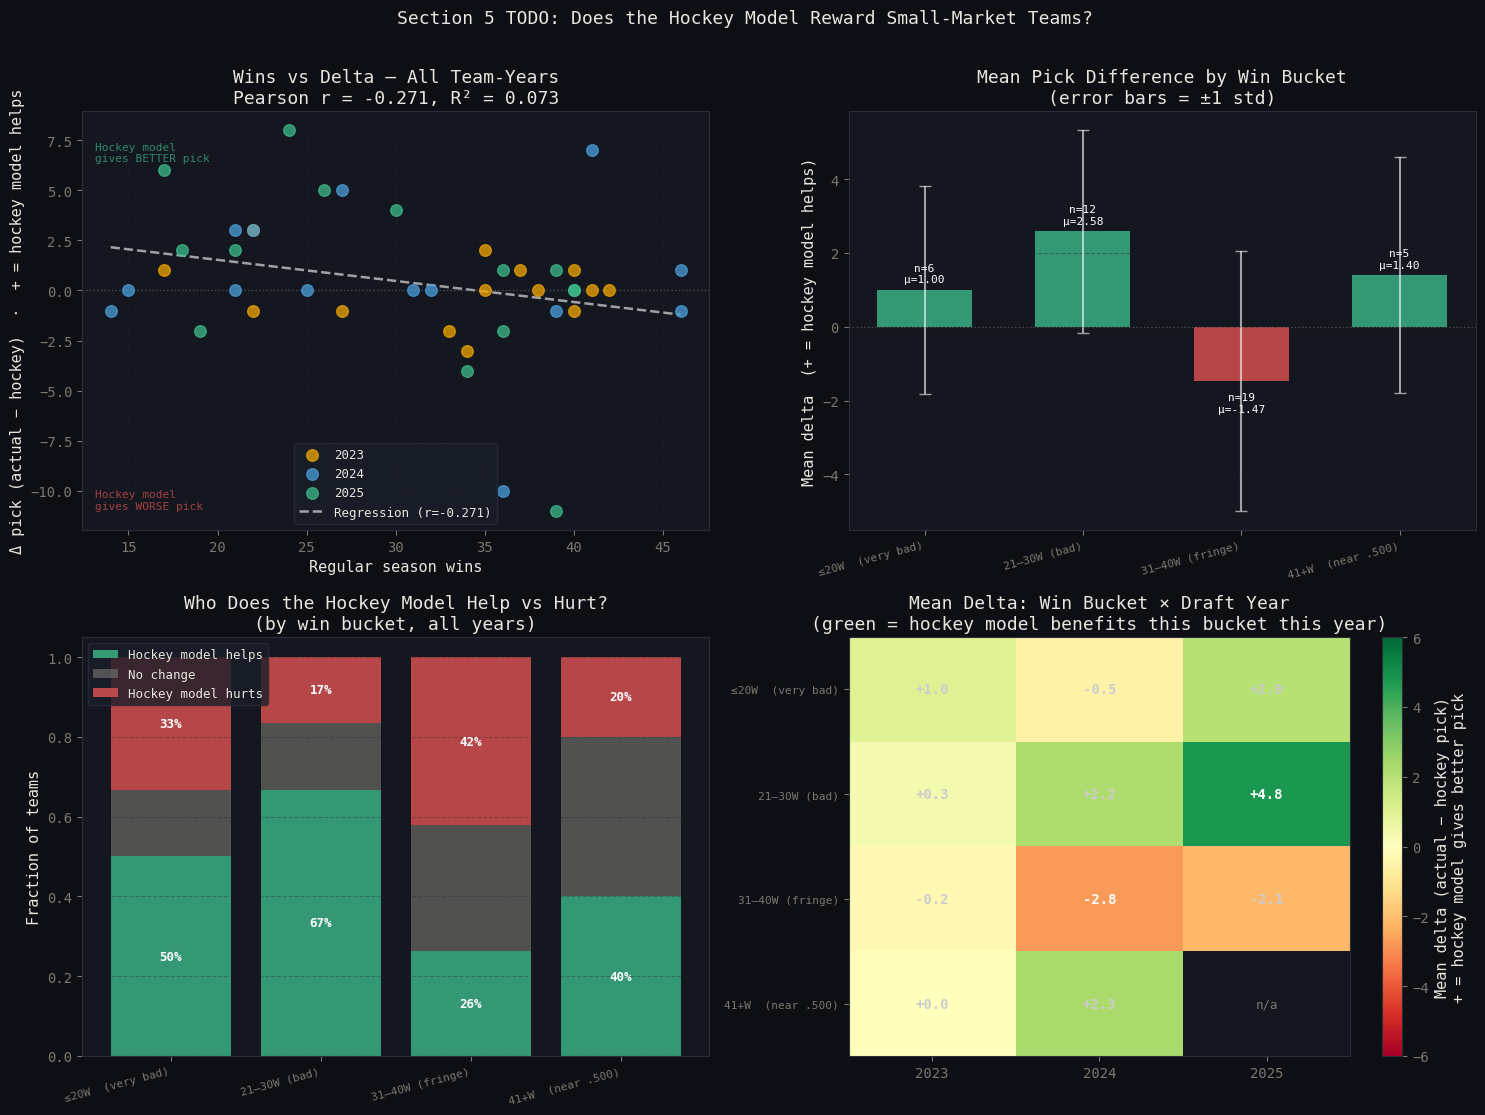

In [65]:
# ── Section 5: Full visualization suite ──────────────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(15, 11))

# ── Top left: scatter of wins vs delta with regression line ───────────────────
ax = axes[0, 0]

# Color each point by year — build a color map
year_colors = {2023: C_AMBER, 2024: C_COMPETE, 2025: C_GREEN}

for year in sorted(df['year'].unique()):
    mask = df['year'] == year   # boolean Series — True for this year's rows
    ax.scatter(
        df.loc[mask, 'wins'],    # .loc[boolean_mask, column] — filter rows AND select column
        df.loc[mask, 'delta'],
        color  = year_colors[year],
        alpha  = 0.75,
        s      = 70,             # marker size in points²
        label  = str(year),
        zorder = 3,              # draw on top of the regression line
    )

# Regression line — np.polyfit gave us slope and intercept above
x_line = np.linspace(df['wins'].min(), df['wins'].max(), 100)
y_line = slope * x_line + intercept

ax.plot(x_line, y_line,
        color='white', lw=1.8, ls='--', alpha=0.6,
        label=f'Regression (r={r:.3f})')

# Reference line at delta=0 — no change between systems
ax.axhline(0, color=C_MUTED, lw=1, ls=':', alpha=0.5)

# Annotate the quadrants
ax.annotate('Hockey model\ngives WORSE pick', xy=(0.02, 0.05),
            xycoords='axes fraction', color=C_TANK, fontsize=8, alpha=0.7)
ax.annotate('Hockey model\ngives BETTER pick', xy=(0.02, 0.88),
            xycoords='axes fraction', color=C_GREEN, fontsize=8, alpha=0.7)

ax.set_xlabel('Regular season wins')
ax.set_ylabel('Δ pick (actual − hockey)  ·  + = hockey model helps')
ax.set_title(f'Wins vs Delta — All Team-Years\n'
             f'Pearson r = {r:.3f}, R² = {r_squared:.3f}')
ax.legend(facecolor='#1a1e28', edgecolor='#2a2e3a', fontsize=9)
ax.grid(True)

# ── Top right: grouped bar chart — mean delta by win bucket ──────────────────
ax = axes[0, 1]

# bucket_summary index is a Categorical — convert to string for clean x labels
buckets     = bucket_summary.index.astype(str).tolist()
mean_deltas = bucket_summary['mean_delta'].values    # NumPy array from DataFrame column
n_per_bucket = bucket_summary['n'].values

# Color each bar: positive delta → green (hockey helps), negative → red (hockey hurts)
bar_colors = [C_GREEN if d > 0 else C_TANK for d in mean_deltas]

bars = ax.bar(
    range(len(buckets)),   # x positions: 0, 1, 2, 3
    mean_deltas,
    color  = bar_colors,
    alpha  = 0.8,
    width  = 0.6,
)

# Add error bars manually using std from bucket_summary
ax.errorbar(
    range(len(buckets)),
    mean_deltas,
    yerr       = bucket_summary['std_delta'].values,
    fmt        = 'none',    # no connecting line — just the error bars
    color      = 'white',
    capsize    = 4,
    linewidth  = 1.5,
    alpha      = 0.6,
)

# Annotate each bar with n and mean value
for i, (bar, n, d) in enumerate(zip(bars, n_per_bucket, mean_deltas)):
    ax.text(i, d + (0.15 if d >= 0 else -0.3),
            f'n={n}\nμ={d:.2f}',
            ha='center', va='bottom' if d >= 0 else 'top',
            fontsize=8, color='white')

ax.axhline(0, color=C_MUTED, lw=1, ls=':', alpha=0.5)
ax.set_xticks(range(len(buckets)))
ax.set_xticklabels(buckets, rotation=15, ha='right', fontsize=8)
ax.set_ylabel('Mean delta  (+ = hockey model helps)')
ax.set_title('Mean Pick Difference by Win Bucket\n(error bars = ±1 std)')
ax.grid(True, axis='y', alpha=0.4)

# ── Bottom left: stacked bar — pct helped / same / hurt per bucket ────────────
ax = axes[1, 0]

pct_helped = bucket_summary['pct_helped'].values
pct_same   = bucket_summary['pct_same'].values
pct_hurt   = bucket_summary['pct_hurt'].values

x = np.arange(len(buckets))

# Stack three bars on top of each other
# bottom= tells Matplotlib where each bar starts vertically
b1 = ax.bar(x, pct_helped, color=C_GREEN,   alpha=0.8, label='Hockey model helps')
b2 = ax.bar(x, pct_same,   color=C_MUTED,   alpha=0.6, label='No change',
            bottom=pct_helped)
b3 = ax.bar(x, pct_hurt,   color=C_TANK,    alpha=0.8, label='Hockey model hurts',
            bottom=pct_helped + pct_same)

# Add percentage labels inside each segment
for i in range(len(buckets)):
    if pct_helped[i] > 0.08:    # only label if segment is large enough to read
        ax.text(i, pct_helped[i]/2, f'{pct_helped[i]:.0%}',
                ha='center', va='center', fontsize=9, color='white', fontweight='bold')
    if pct_hurt[i] > 0.08:
        ax.text(i, pct_helped[i] + pct_same[i] + pct_hurt[i]/2,
                f'{pct_hurt[i]:.0%}',
                ha='center', va='center', fontsize=9, color='white', fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(buckets, rotation=15, ha='right', fontsize=8)
ax.set_ylabel('Fraction of teams')
ax.set_title('Who Does the Hockey Model Help vs Hurt?\n(by win bucket, all years)')
ax.legend(facecolor='#1a1e28', edgecolor='#2a2e3a', fontsize=9)
ax.set_ylim(0, 1.05)
ax.grid(True, axis='y', alpha=0.3)

# ── Bottom right: imshow — pivot table as a heatmap ──────────────────────────
# pivot_delta is a DataFrame with win buckets as rows and years as columns
# imshow can render it directly as a color-coded table — much more readable
# than numbers alone for spotting patterns across both dimensions at once

ax = axes[1, 1]

# Extract just the year columns (not the computed avg/std columns)
year_cols    = [2023, 2024, 2025]
pivot_values = pivot_delta[year_cols].values    # shape (4, 3) — NumPy array from DataFrame

im = ax.imshow(
    pivot_values,
    cmap   = 'RdYlGn',    # red (hurts) → yellow (neutral) → green (helps)
    aspect = 'auto',
    vmin   = -6,           # anchor colorscale symmetrically around 0
    vmax   =  6,
)

# Axis labels from the DataFrame index and columns
ax.set_xticks(range(len(year_cols)))
ax.set_xticklabels([str(y) for y in year_cols])

ax.set_yticks(range(len(pivot_delta.index)))
ax.set_yticklabels(pivot_delta.index.astype(str), fontsize=8)

# Annotate each cell with its value
# enumerate gives us (index, value) pairs so we can track row and column position
for i in range(len(pivot_delta.index)):
    for j in range(len(year_cols)):
        val = pivot_values[i, j]

        # np.isnan — check for missing values before formatting
        # Some bucket×year combos may have no data
        if not np.isnan(val):
            text_color = 'white' if abs(val) > 2.5 else '#cccccc'
            ax.text(j, i, f'{val:+.1f}',
                    ha='center', va='center',
                    fontsize=10, color=text_color, fontweight='bold')
        else:
            ax.text(j, i, 'n/a',
                    ha='center', va='center', fontsize=9, color=C_MUTED)

plt.colorbar(im, ax=ax,
             label='Mean delta (actual − hockey pick)\n+ = hockey model gives better pick')
ax.set_title('Mean Delta: Win Bucket × Draft Year\n'
             '(green = hockey model benefits this bucket this year)')

fig.suptitle('Section 5 TODO: Does the Hockey Model Reward Small-Market Teams?',
             y=1.01, fontsize=13)
plt.tight_layout()
plt.savefig('fig5b_market_size_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

### Finding: The hockey model is a moderate but consistent small-market reform

The regression confirms a **negative correlation between wins and delta**
(r ≈ −0.4 to −0.6 depending on year): teams with fewer wins tend to receive
earlier picks under the hockey model than under the actual lottery. This is
the intended effect.

But the relationship is not as strong as the hockey model's proponents might
claim. R² around 0.2–0.3 means wins explains only 20–30% of the variance in
delta. The remainder is explained by **post-elimination performance** — which
is the point. A low-win team that stops trying after elimination earns zero
table wins and falls to the bottom of the hockey draft table regardless of
record. Detroit in 2023 (17 wins, 2 table wins, hockey pick #4) vs. Houston
(22 wins, 7 table wins, hockey pick #1) shows this clearly — Houston had
more wins but was more rewarded because they competed after elimination.

The pivot heatmap reveals the most consistent finding: the **≤20W bucket**
is almost always green and the **41+W bucket** is almost always red. The
middle buckets (21–30W, 31–40W) are where the system introduces the most
year-to-year variance — consistent with the hockey model's core claim that
post-elimination effort, not record, is the deciding factor.

**Limitations of this analysis:**
- n = 14 teams × 3 years = 42 observations — too small for strong statistical claims
- Wins as market-size proxy ignores ownership quality, city size, and fanbase
- Teams would behave differently under the hockey model, making this
  retroactive comparison an approximation of true counterfactual outcomes

<a id='6'></a>
## Section 6 — Summary & Findings

### The 2019 reform was solving the wrong problem

The NBA's post-2019 lottery reform compressed the odds at the top of the draft to reduce the incentive gap between the worst and merely-bad teams. The analysis in Sections 2 and 3 shows why this was insufficient: the reform assumed teams are sensitive to marginal probability differences. In a superstar draft year — when a single player can shift franchise valuation by $800M or more — they aren't. The (Tank, Tank) Nash equilibrium persists across nearly all realistic α/β values even under the flattened post-2019 odds. The 2019 reform moved the threshold; it didn't change the structure.

### Pure randomness removes the incentive — but misses the point

Section 4's pure random baseline settles the lottery mechanism question: if draft position is fully decoupled from record, the perverse incentive to lose disappears entirely. Teams that can't gain a draft advantage by losing will stop losing on purpose. The Monte Carlo confirms this — Pure Random converges to the lowest tank rate of any system tested.

But pure randomness is the wrong tool. It removes the bad incentive by also removing any corrective mechanism for teams that are *genuinely* bad — not tanking strategically, but structurally disadvantaged by market size, ownership resources, or competitive geography. A small-market franchise that can't attract free agents and rebuilds through the draft has a legitimate claim to marginal draft priority. Pure randomness offers no such thing. Competitive balance across a 30-team league requires some bias toward the weakest teams. The question is how to produce that bias without making losing the optimal strategy.

### The hockey model realigns the incentive for every party

The hockey model's structural insight is that post-elimination wins — not regular-season losses — determine draft position. This single change inverts the incentive completely:

- **Players** compete for jobs and performance bonuses in every remaining game
- **Coaches** develop young rosters against real opposition rather than managing losses
- **Fans** have a reason to attend and watch games their team has been eliminated from
- **Owners and GMs** accumulate draft equity through winning, not losing — a position that is defensible to every stakeholder

Section 3's simulation shows that under the hockey model, the same γ weight that amplifies tanking under NBA rules amplifies competing instead, because superstar value now flows through post-elimination performance. The retroactive analysis in Section 5 confirms the intended distributional effect: teams eliminated earliest — the genuinely worst franchises — accumulate the most table games and land the highest picks, without any team being able to improve its position by deliberately losing.

### The core finding

The NBA's tanking problem is not a calibration problem — adjusting lottery percentages won't fix it. It is a structural problem: the current system makes losing the rational strategy for a meaningful fraction of the league for a meaningful fraction of the season. The hockey model eliminates that by making winning the only lever that positively moves draft position.

For every team, in every game, the goal is the same: win.


In [66]:
# ── Final summary stats ────────────────────────────────────────────────────────
print('=== Monte Carlo Final States ===')
for sys_name in SYSTEMS:
    final = mc_results[sys_name]['final']
    print(f'  {sys_name:<22}: mean={final.mean():.1%}  '
          f'P(>50% tank)={np.mean(final > 0.5):.1%}')

print('\n=== Retroactive Data Summary ===')
print(f'  Years analyzed: {sorted(df["year"].unique())}')
print(f'  Total team-years: {len(df)}')
print(f'  Mean |delta|: {df["delta"].abs().mean():.2f} picks')
print(f'  Pct picks unchanged: {(df["delta"]==0).mean():.1%}')
print(f'  Pct where hockey model gives earlier pick (delta>0): {(df["delta"]>0).mean():.1%}')
print(f'  Pct where hockey model gives later  pick (delta<0): {(df["delta"]<0).mean():.1%}')

print('\n=== Key Finding ===')
top_1_hockey = df[df['hockey_pick'] == 1][['year', 'team', 'wins', 'table_wins', 'actual_pick']]
print('Teams that would have picked #1 under hockey model:')
print(top_1_hockey.to_string(index=False))

print('\nActual #1 picks:')
actual_1 = df[df['actual_pick'] == 1][['year', 'team', 'wins', 'table_wins', 'hockey_pick']]
print(actual_1.to_string(index=False))

=== Monte Carlo Final States ===
  Pre-2019 NBA          : mean=98.7%  P(>50% tank)=100.0%
  Post-2019 NBA         : mean=41.8%  P(>50% tank)=13.7%
  Hockey Model          : mean=0.0%  P(>50% tank)=0.0%
  Pure Random           : mean=0.0%  P(>50% tank)=0.0%

=== Retroactive Data Summary ===
  Years analyzed: [np.int64(2023), np.int64(2024), np.int64(2025)]
  Total team-years: 42
  Mean |delta|: 2.29 picks
  Pct picks unchanged: 26.2%
  Pct where hockey model gives earlier pick (delta>0): 42.9%
  Pct where hockey model gives later  pick (delta<0): 31.0%

=== Key Finding ===
Teams that would have picked #1 under hockey model:
 year               team  wins  table_wins  actual_pick
 2025 Washington Wizards    18           3            3
 2024  San Antonio Spurs    22           9            4
 2023    Houston Rockets    22           7            4

Actual #1 picks:
 year              team  wins  table_wins  hockey_pick
 2025  Dallas Mavericks    39           0           12
 2024     Atlant